# Hotel Bar Inventory Forecasting & Par Level Recommendation System

**Business problem.** Bar managers face two opposite failures: **stockouts** of popular brands (lost revenue, unhappy guests, interrupted service) and **overstock** of slow movers (tied-up cash, scarce backroom space, shrinkage/spoilage). This notebook turns raw bottle-balance transaction logs into a **daily demand series per Bar x Brand**, forecasts demand, converts forecasts into **dynamic par levels** (`Par = lead-time demand + Z x sigma x sqrt(L)`), and **back-tests** the policy against a static-par baseline.

| Assignment step | Where it is covered |
|---|---|
| Step 1 - Data understanding & preprocessing (timestamps, conservation check, daily grid, zero days) | Sections 1-2 |
| Step 2 - EDA (ABC velocity, day-of-week seasonality, stockout audit) | Section 3 |
| Step 3 - Demand forecasting (temporal split; baseline -> Holt-Winters -> ML; MAE / RMSE / WAPE) | Section 4 |
| Step 4 - Par level & safety stock | Section 5 |
| Step 5 - Inventory simulation engine (stockouts, lost volume, average stock, turnover) | Section 6 |
| Step 6 - Report + video (auto-generated from the numbers in this notebook) | Sections 7-8 |

**How to run:** put the dataset at `data/raw/bar_inventory_data.csv`, then *Kernel -> Restart & Run All*. Every setting lives in the config cell below. Running the last cells writes `report/business_report.pdf`, `video_script/video_walkthrough_outline.md` and the processed CSV.

In [1]:
import re, json, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from IPython.display import display, Markdown
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60, "display.width", 170, "display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 140, "axes.titleweight": "bold", "figure.autolayout": True})

# ============================ CONFIG (edit only here) ============================
ROOT      = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH  = ROOT / "data/raw/bar_inventory_data.csv"
PROC_PATH = ROOT / "data/processed/daily_bar_consumption.csv"
FIG_DIR, TAB_DIR = ROOT / "report/figures", ROOT / "report/tables"
for p in (PROC_PATH.parent, FIG_DIR, TAB_DIR, ROOT / "video_script"):
    p.mkdir(parents=True, exist_ok=True)

SERIES_KEYS = ["Bar Name", "Brand Name"]      # add a property/hotel column here if the data has one
UNIT_TO_ML  = 1.0        # multiply raw quantities by this to get ml (1.0 if the file is already in ml)
BOTTLE_ML   = 750        # standard bottle size (assumption), used only if ROUND_PAR_TO_BOTTLE is True
ROUND_PAR_TO_BOTTLE = False   # the brief's par formula has no rounding; typical daily use here is a small fraction of a bottle
BUSINESS_DAY_CUTOFF_HOURS = 0   # e.g. 4 -> a pour at 01:30 counts toward the previous business day
CONSERVATION_TOL_ML = 1.0       # tolerance for Closing = Opening + Purchase - Consumed

LEAD_TIME_DAYS      = 2                    # supplier lead time L (days)
LEAD_TIMES_TO_TEST  = [1, 2, 3]            # sensitivity grid (max value = forecast horizon trained)
SERVICE_LEVEL       = 0.95                 # 95% -> Z = 1.645
SERVICE_LEVELS_TO_TEST = [0.90, 0.95, 0.99]
Z = float(norm.ppf(SERVICE_LEVEL))

TRAIN_FRAC       = 0.80    # temporal split: first 80% of days train, last 20% test (no random k-fold)
MIN_HISTORY_DAYS = 56      # a bar-brand series needs this much history before the split to be modelled
SIGMA_WINDOW, SIGMA_MIN = 56, 28           # trailing window for the forecast-error RMSE (safety stock): 8 weeks = several weekly cycles and ~9 demand events; see the sensitivity table in section 6
MIN_ORDER_ML = BOTTLE_ML   # practical variant only: every replenishment order is at least one standard bottle
SELECTION_METRIC = "RMSE lead-time demand"   # model used for par levels = lowest value of this metric on the test window
RF_TREES, RF_ROW_CAP = 120, 100_000
RANDOM_STATE = 42
KMAX = max(LEAD_TIMES_TO_TEST)
assert LEAD_TIME_DAYS in LEAD_TIMES_TO_TEST and 1 <= KMAX <= 7
print(f"Project root: {ROOT}\nLead time L={LEAD_TIME_DAYS} d | service level {SERVICE_LEVEL:.0%} -> Z={Z:.3f} | split {TRAIN_FRAC:.0%}/{1-TRAIN_FRAC:.0%}")

Project root: /Users/arunananthula/Downloads/bar_inventory_project
Lead time L=2 d | service level 95% -> Z=1.645 | split 80%/20%


## 1. Data understanding & preprocessing

**Dataset note.** The assignment dataset was supplied as a 178-page Google-Sheets PDF (6,575 rows; columns `Date Time Served, Bar Name, Alcohol Type, Brand Name, Opening Balance (ml), Purchase (ml), Consumed (ml), Closing Balance (ml)`). It was converted to `data/raw/bar_inventory_data.csv` with `data/raw/pdf_to_csv.py`. The PDF printed 234 balance cells in rounded scientific notation (3 significant digits) and ~2,000 floating-point residuals (~1e-13, i.e. zero); the exact values were **reconstructed from the conservation chain** using the exactly-printed `Purchase` / `Consumed` values, and the residuals were set to 0.

Steps: parse timestamps -> standardise column/name spellings -> drop exact duplicates -> **verify the conservation equation** `Closing = Opening + Purchase - Consumed` (row level and daily level) -> check balance continuity between consecutive rows. Every check is logged in a data-quality table that feeds the report.

In [2]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f"Dataset not found. Put the CSV at: {RAW_PATH}")
raw = pd.read_csv(RAW_PATH)
print(f"Loaded {raw.shape[0]:,} rows x {raw.shape[1]} columns from {RAW_PATH.name}")
display(raw.head(8)); display(raw.dtypes.to_frame("dtype").T)

# ---- map whatever the headers are called to canonical names --------------------------------
def find_col(cols, *patterns, used=()):
    for p in patterns:
        for c in cols:
            if c not in used and re.search(p, str(c), flags=re.I):
                return c
    raise KeyError(f"No column matching {patterns}. Columns present: {list(cols)}")

CANON = {}
for canon, pats in [("Date Time Served", (r"date.*time", r"served", r"timestamp", r"date")),
                    ("Bar Name",         (r"bar", r"outlet", r"location")),
                    ("Brand Name",       (r"brand", r"item", r"product", r"sku")),
                    ("Opening Balance",  (r"open",)),
                    ("Purchase",         (r"purchas", r"receiv", r"restock")),
                    ("Consumed (ml)",    (r"consum",)),
                    ("Closing Balance",  (r"clos",))]:
    CANON[canon] = find_col(raw.columns, *pats, used=CANON.values())
print("\nColumn mapping:", {k: v for k, v in CANON.items()})
df = raw.rename(columns={v: k for k, v in CANON.items()}).copy()
QTY = ["Opening Balance", "Purchase", "Consumed (ml)", "Closing Balance"]
DQ = []   # data-quality log: (check, count, action)
DQ.append(("Raw rows loaded", len(df), "-"))

Loaded 6,575 rows x 8 columns from bar_inventory_data.csv


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,"1,344.370",0.000,0.000,"1,344.370"
1,2023-01-01 10:28:00,Brown's Bar,Vodka,Grey Goose,"2,560.440",0.000,0.000,"2,560.440"
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,"1,034.280",0.000,0.000,"1,034.280"
3,2023-01-01 11:32:00,Anderson's Bar,Whiskey,Jim Beam,872.080,0.000,0.000,872.080
4,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,"2,194.530",0.000,0.000,"2,194.530"
5,2023-01-01 14:47:00,Brown's Bar,Whiskey,Jim Beam,826.200,0.000,0.000,826.200
6,2023-01-01 15:31:00,Taylor's Bar,Wine,Sutter Home,"2,343.940",0.000,0.000,"2,343.940"
7,2023-01-01 15:55:00,Anderson's Bar,Rum,Bacardi,"1,109.090",0.000,0.000,"1,109.090"


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
dtype,object,object,object,object,float64,float64,float64,float64



Column mapping: {'Date Time Served': 'Date Time Served', 'Bar Name': 'Bar Name', 'Brand Name': 'Brand Name', 'Opening Balance': 'Opening Balance (ml)', 'Purchase': 'Purchase (ml)', 'Consumed (ml)': 'Consumed (ml)', 'Closing Balance': 'Closing Balance (ml)'}


In [3]:
# ---- timestamps ------------------------------------------------------------------------------
ts = pd.to_datetime(df["Date Time Served"], errors="coerce")
if ts.isna().mean() > 0.05:                       # maybe day-first dates
    ts2 = pd.to_datetime(df["Date Time Served"], errors="coerce", dayfirst=True)
    if ts2.isna().sum() < ts.isna().sum():
        ts = ts2; print("Timestamps parsed with dayfirst=True")
df["Date Time Served"] = ts

# ---- numeric quantities -> ml ----------------------------------------------------------------
for c in QTY:
    df[c] = pd.to_numeric(df[c], errors="coerce") * UNIT_TO_ML
n_purchase_nan = int(df["Purchase"].isna().sum()); df["Purchase"] = df["Purchase"].fillna(0.0)

# derive Consumed when it is missing but both balances exist (conservation equation)
miss_c = df["Consumed (ml)"].isna() & df[["Opening Balance", "Closing Balance"]].notna().all(axis=1)
df.loc[miss_c, "Consumed (ml)"] = (df.loc[miss_c, "Opening Balance"] + df.loc[miss_c, "Purchase"] - df.loc[miss_c, "Closing Balance"])
DQ.append(("Missing Purchase (set to 0)", n_purchase_nan, "filled with 0"))
DQ.append(("Missing Consumed derived from balances", int(miss_c.sum()), "Opening + Purchase - Closing"))

# ---- drop unusable rows ----------------------------------------------------------------------
bad = df["Date Time Served"].isna() | df["Bar Name"].isna() | df["Brand Name"].isna() | df["Consumed (ml)"].isna()
DQ.append(("Rows with unparseable time / missing bar, brand or consumption", int(bad.sum()), "dropped"))
df = df.loc[~bad].copy()

# ---- unify spelling / case / whitespace of names (keep the most frequent spelling) ------------
def canonicalise(s):
    s = s.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    key = s.str.casefold()
    best = s.groupby(key).agg(lambda x: x.value_counts().idxmax())
    return key.map(best), int((s != key.map(best)).sum())
df["Bar Name"], n1 = canonicalise(df["Bar Name"]); df["Brand Name"], n2 = canonicalise(df["Brand Name"])
DQ.append(("Bar/Brand name spelling variants unified", n1 + n2, "canonical spelling applied"))

# ---- exact duplicates ------------------------------------------------------------------------
dups = df.duplicated(keep="first"); DQ.append(("Exact duplicate rows", int(dups.sum()), "dropped")); df = df.loc[~dups].copy()

# ---- negative consumption (returns / corrections) --------------------------------------------
neg = df["Consumed (ml)"] < 0; DQ.append(("Negative Consumed values", int(neg.sum()), "clipped to 0 for demand"))
df["Consumed (ml)"] = df["Consumed (ml)"].clip(lower=0)

# ---- CONSERVATION CHECK: Closing = Opening + Purchase - Consumed -----------------------------
df["resid"] = df["Closing Balance"] - (df["Opening Balance"] + df["Purchase"] - df["Consumed (ml)"])
df["conservation_ok"] = df["resid"].abs() <= CONSERVATION_TOL_ML
viol = ~df["conservation_ok"]
share_vol = df.loc[viol, "Consumed (ml)"].sum() / max(df["Consumed (ml)"].sum(), 1e-9)
DQ.append(("Rows violating Closing = Opening + Purchase - Consumed", int(viol.sum()),
           f"flagged, kept ({share_vol:.2%} of consumed volume)"))
print(f"Conservation equation holds on {(~viol).mean():.2%} of rows ({int(viol.sum()):,} violations, {share_vol:.2%} of volume).")
if viol.any():
    display(df.loc[viol, ["Date Time Served", "Bar Name", "Brand Name", "Opening Balance", "Purchase", "Consumed (ml)", "Closing Balance", "resid"]].head(10))
    display(df.loc[viol].groupby("Bar Name").size().rename("violations").to_frame().T)

# ---- CONTINUITY CHECK: closing of one row = opening of the next row of the same bar-brand ------
df["_order"] = np.arange(len(df))
df = df.sort_values(SERIES_KEYS + ["Date Time Served", "_order"], kind="stable").reset_index(drop=True)
prev_close = df.groupby(SERIES_KEYS)["Closing Balance"].shift(1)
gap = (df["Opening Balance"] - prev_close).abs() > CONSERVATION_TOL_ML
gap &= prev_close.notna()
DQ.append(("Opening != previous closing (same bar-brand)", int(gap.sum()), "flagged only (unrecorded movements/transfers)"))
print(f"Balance continuity: {gap.mean():.2%} of rows have an opening balance different from the previous closing.")

# ---- unit sanity check -----------------------------------------------------------------------
med_pos = df.loc[df["Consumed (ml)"] > 0, "Consumed (ml)"].median()
print(f"Median positive consumption per transaction: {med_pos:,.1f} ml")
if med_pos < 20:
    print("WARNING: values look like bottle counts (not ml). Set UNIT_TO_ML (e.g. 750) and re-run.")
dq_table = pd.DataFrame(DQ, columns=["Check", "Rows", "Action"]); display(dq_table)
dq_table.to_csv(TAB_DIR / "data_quality_log.csv", index=False)

Conservation equation holds on 100.00% of rows (0 violations, 0.00% of volume).
Balance continuity: 0.00% of rows have an opening balance different from the previous closing.
Median positive consumption per transaction: 342.9 ml


,Check,Rows,Action
0,Raw rows loaded,6575,-
1,Missing Purchase (set to 0),0,filled with 0
2,Missing Consumed derived from balances,0,Opening + Purchase - Closing
3,"Rows with unparseable time / missing bar, bran...",0,dropped
4,Bar/Brand name spelling variants unified,0,canonical spelling applied
5,Exact duplicate rows,0,dropped
6,Negative Consumed values,0,clipped to 0 for demand
7,Rows violating Closing = Opening + Purchase - ...,0,"flagged, kept (0.00% of consumed volume)"
8,Opening != previous closing (same bar-brand),0,flagged only (unrecorded movements/transfers)


## 2. Aggregate to a regular daily grid (per Bar x Brand)

Raw transactions are irregular, so we sum consumption per **Bar x Brand x Day**. We then reindex to a **full daily calendar for every observed Bar-Brand pair** (from the pair's first record to the last date in the data) and insert explicit **zero-demand days**, so the models learn intermittent demand. We only build grids for pairs that actually occur, rather than a full Cartesian product, to avoid inventing bar-brand combinations that are never stocked. Balances are carried forward on days without transactions.

In [4]:
df["Date"] = (df["Date Time Served"] - pd.Timedelta(hours=BUSINESS_DAY_CUTOFF_HOURS)).dt.floor("D")
series_keys = df[SERIES_KEYS].drop_duplicates().sort_values(SERIES_KEYS).reset_index(drop=True)
series_keys["sid"] = np.arange(len(series_keys))
df = df.merge(series_keys, on=SERIES_KEYS, how="left")

daily = (df.groupby(["sid", "Date"])
           .agg(consumed=("Consumed (ml)", "sum"), purchase=("Purchase", "sum"),
                opening=("Opening Balance", "first"), closing=("Closing Balance", "last"),
                tx=("Consumed (ml)", "size")).reset_index())

last_date = daily["Date"].max()
first_date = daily.groupby("sid")["Date"].min()
grid = pd.concat([pd.DataFrame({"sid": sid, "Date": pd.date_range(fd, last_date, freq="D")}) for sid, fd in first_date.items()], ignore_index=True)
full = grid.merge(daily, on=["sid", "Date"], how="left").merge(series_keys, on="sid", how="left")
full = full.sort_values(["sid", "Date"]).reset_index(drop=True)
full["closing"] = full.groupby("sid")["closing"].ffill()
full["opening"] = full["opening"].fillna(full["closing"])
for c in ["consumed", "purchase", "tx"]:
    full[c] = full[c].fillna(0.0)

mean_c = full.groupby("sid")["consumed"].transform("mean")
full["stockout_flag"] = ((full["closing"] <= 1e-6) & (mean_c > 0)).astype(int)                 # Closing == 0 while demand history is non-zero
full["stockout_in_service"] = ((full["stockout_flag"] == 1) & (full["consumed"] > 0)).astype(int)
full["dow"] = full["Date"].dt.dayofweek
full["Day of Week"] = full["Date"].dt.day_name()
n_zero = int((full["consumed"] == 0).sum())

# daily-level conservation check on days that had transactions
act = full["tx"] > 0
daily_ok = ((full.loc[act, "opening"] + full.loc[act, "purchase"] - full.loc[act, "consumed"] - full.loc[act, "closing"]).abs() <= CONSERVATION_TOL_ML * 5)
DQ.append(("Daily-level conservation holds (active days)", f"{daily_ok.mean():.2%}", "informational"))

out = full.rename(columns={"consumed": "Consumed (ml)", "purchase": "Purchase (ml)", "opening": "Opening Balance",
                           "closing": "Closing Balance", "tx": "Transactions", "stockout_flag": "Stockout Flag"})
out[["Date", "Bar Name", "Brand Name", "Consumed (ml)", "Purchase (ml)", "Opening Balance", "Closing Balance",
     "Transactions", "Day of Week", "Stockout Flag"]].to_csv(PROC_PATH, index=False)
print(f"Saved {PROC_PATH.relative_to(ROOT)}: {len(full):,} rows | {full['Bar Name'].nunique()} bars | {full['Brand Name'].nunique()} brands | "
      f"{len(series_keys)} bar-brand series | {full['Date'].min().date()} -> {full['Date'].max().date()}")
print(f"Explicit zero-demand days added/kept: {n_zero:,} ({n_zero/len(full):.1%} of all series-days)")
print(f"Daily-level conservation holds on {daily_ok.mean():.2%} of active days")
display(out[["Date", "Bar Name", "Brand Name", "Consumed (ml)", "Purchase (ml)", "Closing Balance", "Stockout Flag"]].head())

Saved data/processed/daily_bar_consumption.csv: 34,769 rows | 6 bars | 16 brands | 96 bar-brand series | 2023-01-01 -> 2024-01-01
Explicit zero-demand days added/kept: 29,104 (83.7% of all series-days)
Daily-level conservation holds on 100.00% of active days


,Date,Bar Name,Brand Name,Consumed (ml),Purchase (ml),Closing Balance,Stockout Flag
0,2023-01-02,Anderson's Bar,Absolut,118.620,0.000,"1,191.300",0
1,2023-01-03,Anderson's Bar,Absolut,0.000,0.000,"1,191.300",0
2,2023-01-04,Anderson's Bar,Absolut,0.000,0.000,"1,191.300",0
3,2023-01-05,Anderson's Bar,Absolut,463.200,0.000,728.100,0
4,2023-01-06,Anderson's Bar,Absolut,453.020,0.000,275.080,0


## 3. Exploratory data analysis

**Velocity (ABC)** by brand volume: A = first 80% of cumulative volume, B = next 15%, C = last 5%. **Seasonality**: demand index by day of week. **Stockout audit**: days where `Closing Balance == 0` for a series with non-zero historical demand.

,brands,volume_ml,volume_share
class,,,
A,13,"1,676,902.600",0.852
B,2,"194,966.410",0.099
C,1,"96,812.650",0.049


Median zero-demand share per series: 83.8%; series with >50% zero days: 100.0%
Median average demand interval (ADI): 6.2 days between demand events


,intermittent
series,96


,volume_ml,zero_share,zero_stock_share,volume_share
Alcohol Type,,,,
Vodka,"411,759.710",0.821,0.155,0.209
Beer,"399,498.390",0.870,0.144,0.203
Rum,"393,266.840",0.826,0.154,0.200
Whiskey,"384,754.460",0.827,0.143,0.195
Wine,"379,402.260",0.830,0.163,0.193


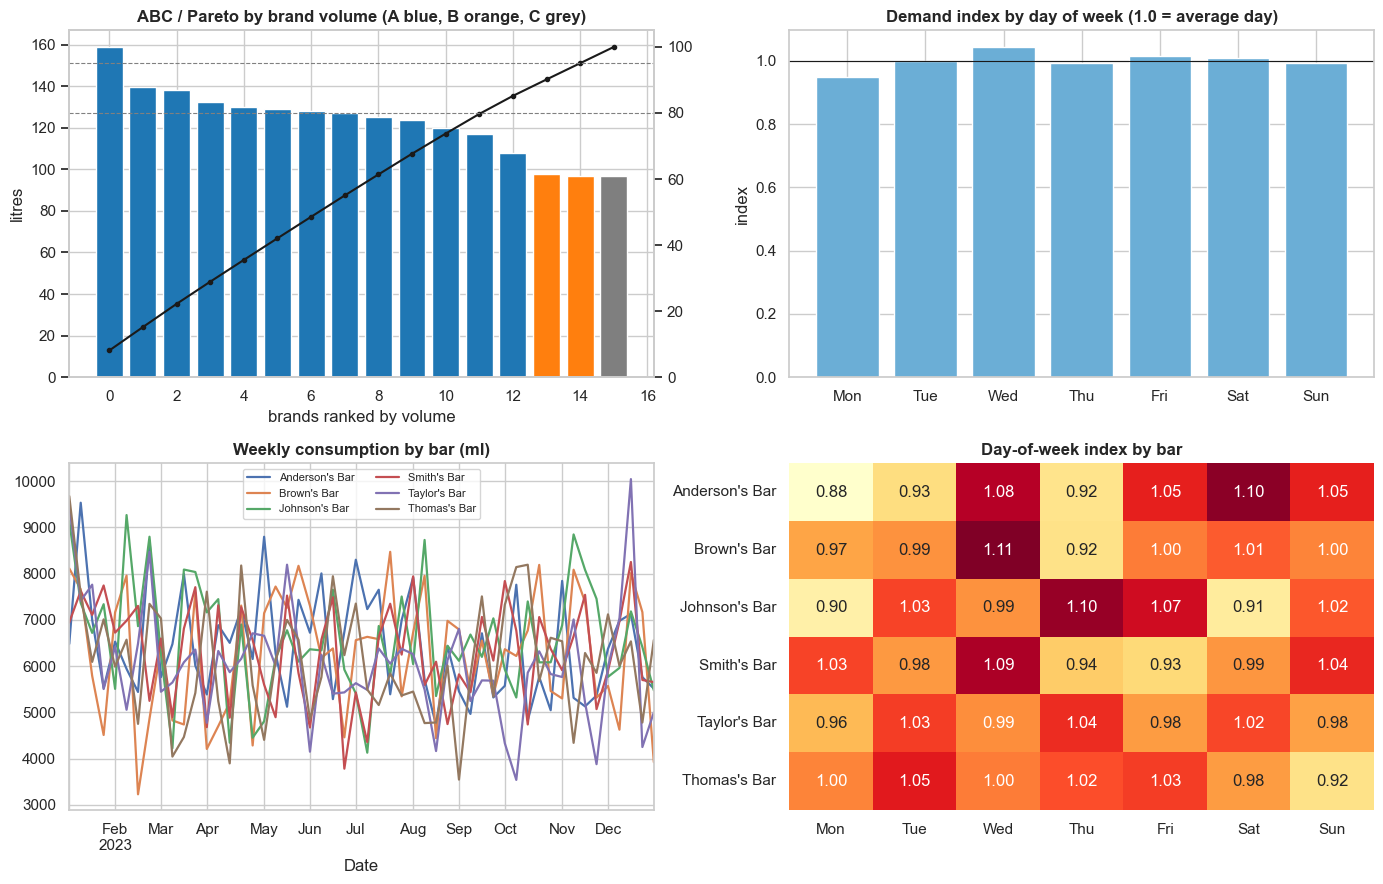

Strongest demand days: Wed (1.04x average) and Fri; weakest day index 0.95x -> max/min ratio 1.10
No material weekly seasonality: demand is driven by irregular demand events, not by the day of the week.


In [5]:
# ---------- ABC classification (brand level) ----------
brand_tot = full.groupby("Brand Name")["consumed"].sum().sort_values(ascending=False)
cum_share = brand_tot.cumsum() / brand_tot.sum()
abc = pd.Series(np.where(cum_share.shift(fill_value=0) < 0.80, "A", np.where(cum_share.shift(fill_value=0) < 0.95, "B", "C")), index=brand_tot.index)
series_keys["ABC"] = series_keys["Brand Name"].map(abc)
full["ABC"] = full["Brand Name"].map(abc)
abc_tbl = (pd.DataFrame({"volume_ml": brand_tot, "cum_share": cum_share, "class": abc}).groupby("class")
           .agg(brands=("volume_ml", "size"), volume_ml=("volume_ml", "sum")))
abc_tbl["volume_share"] = abc_tbl["volume_ml"] / abc_tbl["volume_ml"].sum()
display(abc_tbl)

# ---------- descriptive stats ----------
per_series = full.groupby("sid").agg(mean_ml=("consumed", "mean"), zero_share=("consumed", lambda x: (x == 0).mean()))
print(f"Median zero-demand share per series: {per_series['zero_share'].median():.1%}; series with >50% zero days: {(per_series['zero_share'] > 0.5).mean():.1%}")
# demand-pattern classification (Syntetos-Boylan): ADI = average days between demands, CV2 = squared coeff. of variation of non-zero demand sizes
pos = full[full["consumed"] > 0].groupby("sid")["consumed"].agg(["mean", "std", "size"]); pos["std"] = pos["std"].fillna(0)
adi = full.groupby("sid").size() / pos["size"]; cv2 = (pos["std"] / pos["mean"]) ** 2
demand_pattern = pd.Series(np.where(adi < 1.32, np.where(cv2 < 0.49, "smooth", "erratic"), np.where(cv2 < 0.49, "intermittent", "lumpy")), index=pos.index).value_counts()
ADI_MEDIAN = float(adi.median())
print(f"Median average demand interval (ADI): {ADI_MEDIAN:.1f} days between demand events")
display(demand_pattern.to_frame("series").T.rename_axis(None))
if "Alcohol Type" in df.columns:
    tmap = df.drop_duplicates("Brand Name").set_index("Brand Name")["Alcohol Type"]; full["Alcohol Type"] = full["Brand Name"].map(tmap)
    type_tbl = full.groupby("Alcohol Type").agg(volume_ml=("consumed", "sum"), zero_share=("consumed", lambda x: (x == 0).mean()), zero_stock_share=("stockout_flag", "mean"))
    type_tbl["volume_share"] = type_tbl["volume_ml"] / type_tbl["volume_ml"].sum(); display(type_tbl.sort_values("volume_ml", ascending=False))

# ---------- day-of-week & trend ----------
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
tot_day = full.groupby("Date")["consumed"].sum().to_frame("total"); tot_day["dow"] = tot_day.index.dayofweek
dow_index = tot_day.groupby("dow")["total"].mean() / tot_day["total"].mean()
bar_dow = full.groupby(["Bar Name", "dow"])["consumed"].mean().unstack()
bar_dow = bar_dow.div(bar_dow.mean(axis=1), axis=0); bar_dow.columns = dow_names
weekly = full.groupby([pd.Grouper(key="Date", freq="W"), "Bar Name"])["consumed"].sum().unstack()
if len(weekly) > 4: weekly = weekly.iloc[1:-1]      # drop partial first/last week

fig, ax = plt.subplots(2, 2, figsize=(14, 9))
ax[0, 0].bar(range(len(brand_tot)), brand_tot.values / 1000, color=abc.map({"A": "#1f77b4", "B": "#ff7f0e", "C": "#7f7f7f"}).values)
a2 = ax[0, 0].twinx(); a2.plot(range(len(brand_tot)), cum_share.values * 100, color="k", marker=".")
a2.axhline(80, ls="--", c="grey", lw=.8); a2.axhline(95, ls="--", c="grey", lw=.8); a2.set_ylim(0, 105); a2.grid(False)
ax[0, 0].set_title("ABC / Pareto by brand volume (A blue, B orange, C grey)"); ax[0, 0].set_ylabel("litres"); ax[0, 0].set_xlabel("brands ranked by volume")
ax[0, 1].bar(dow_names, dow_index.values, color="#6baed6"); ax[0, 1].axhline(1, c="k", lw=.8)
ax[0, 1].set_title("Demand index by day of week (1.0 = average day)"); ax[0, 1].set_ylabel("index")
weekly.plot(ax=ax[1, 0], lw=1.6); ax[1, 0].set_title("Weekly consumption by bar (ml)"); ax[1, 0].legend(fontsize=8, ncol=2)
sns.heatmap(bar_dow, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax[1, 1], cbar=False); ax[1, 1].set_title("Day-of-week index by bar"); ax[1, 1].set_ylabel("")
fig.savefig(FIG_DIR / "eda_overview.png"); plt.show()
peak_days = [dow_names[i] for i in dow_index.sort_values(ascending=False).index[:2]]
DOW_RATIO = float(dow_index.max() / dow_index.min()); WEEKDAY_EFFECT = DOW_RATIO >= 1.25      # is there a material weekly cycle?
print(f"Strongest demand days: {peak_days[0]} ({dow_index.max():.2f}x average) and {peak_days[1]}; weakest day index {dow_index.min():.2f}x -> max/min ratio {DOW_RATIO:.2f}")
print("Material weekly seasonality detected." if WEEKDAY_EFFECT else "No material weekly seasonality: demand is driven by irregular demand events, not by the day of the week.")

Historical stockout series-days (closing balance = 0): 5,261 of 34,769 = 15.13%
Records where consumption was capped by available stock (stock ran out while serving): 264 of 6,575 records = 4.0% -> demand on those days is censored
Indicative lost demand on those days (censored, estimated): 245.1 litres


,stockout_days,rate
Bar Name,,
Thomas's Bar,1109,0.191
Taylor's Bar,1069,0.184
Anderson's Bar,886,0.153
Brown's Bar,872,0.150
Smith's Bar,758,0.131
Johnson's Bar,567,0.098


,stockout_days,rate
ABC,,
A,4470,0.158
B,608,0.140
C,183,0.085


,median days of cover held
ABC,
A,29.202
B,51.775
C,50.646


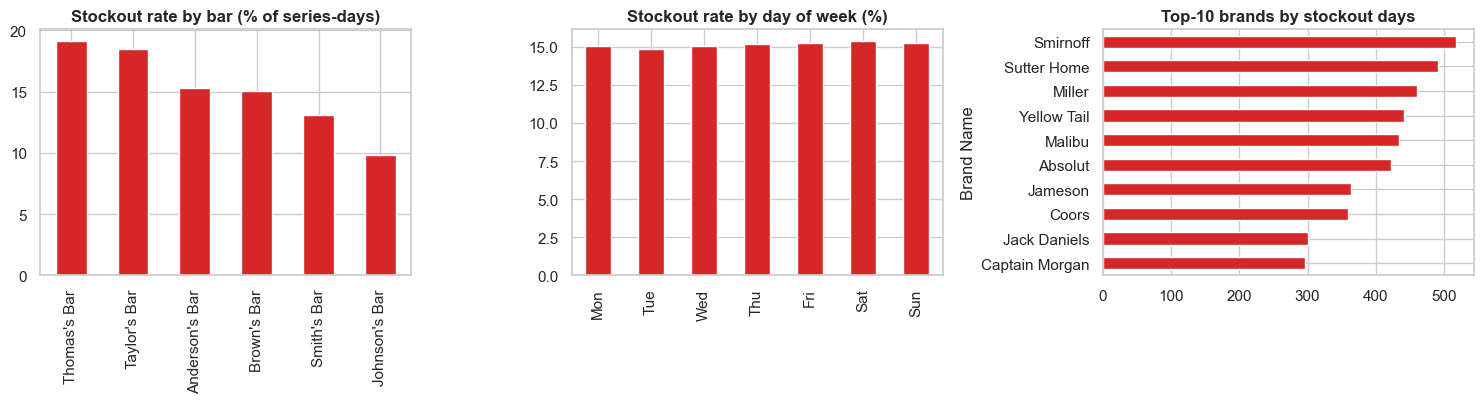

In [6]:
# ---------- STOCKOUT AUDIT ----------
tot_sd = len(full); so_days = int(full["stockout_flag"].sum())
so_by_bar = full.groupby("Bar Name")["stockout_flag"].agg(["sum", "mean"]).rename(columns={"sum": "stockout_days", "mean": "rate"}).sort_values("rate", ascending=False)
so_by_brand = full.groupby("Brand Name")["stockout_flag"].agg(["sum", "mean"]).rename(columns={"sum": "stockout_days", "mean": "rate"}).sort_values("stockout_days", ascending=False)
so_by_abc = full.groupby("ABC")["stockout_flag"].agg(["sum", "mean"]).rename(columns={"sum": "stockout_days", "mean": "rate"})
so_by_dow = full.groupby("dow")["stockout_flag"].mean(); so_by_dow.index = dow_names

# indicative lost demand: expected same-weekday demand minus what was actually sold on stockout days (demand is censored there)
dow_mean = full.groupby(["sid", "dow"])["consumed"].transform("mean")
full["lost_est"] = np.where(full["stockout_flag"] == 1, np.clip(dow_mean - full["consumed"], 0, None), 0.0)
est_lost_ml = float(full["lost_est"].sum())

# days of cover held (overstock indicator): average closing balance / average daily demand
cover = (full.groupby("sid").agg(close=("closing", "mean"), dem=("consumed", "mean")).join(series_keys.set_index("sid")["ABC"]))
cover = cover[cover["dem"] > 0]; cover["days_cover"] = cover["close"] / cover["dem"]
cover_abc = cover.groupby("ABC")["days_cover"].median()

n_capped = int(full["stockout_in_service"].sum()); n_rec = int((full["tx"] > 0).sum())
print(f"Historical stockout series-days (closing balance = 0): {so_days:,} of {tot_sd:,} = {so_days/tot_sd:.2%}")
print(f"Records where consumption was capped by available stock (stock ran out while serving): {n_capped:,} of {n_rec:,} records = {n_capped/max(n_rec,1):.1%} -> demand on those days is censored")
print(f"Indicative lost demand on those days (censored, estimated): {est_lost_ml/1000:,.1f} litres")
display(so_by_bar); display(so_by_abc); display(cover_abc.to_frame("median days of cover held"))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
so_by_bar["rate"].mul(100).plot.bar(ax=ax[0], color="#d62728"); ax[0].set_title("Stockout rate by bar (% of series-days)"); ax[0].set_xlabel("")
so_by_dow.mul(100).plot.bar(ax=ax[1], color="#d62728"); ax[1].set_title("Stockout rate by day of week (%)")
so_by_brand["stockout_days"].head(10).iloc[::-1].plot.barh(ax=ax[2], color="#d62728"); ax[2].set_title("Top-10 brands by stockout days")
fig.savefig(FIG_DIR / "stockout_audit.png"); plt.show()

## 4. Demand forecasting

**Set-up.** Strict **temporal split** (first 80% of days = train, last 20% = test; no random k-fold). For every forecast *origin* day `t` (end of day, after seeing `t`'s consumption) we forecast demand for days `t+1 ... t+K`. This directly gives what a par level needs: **demand during the lead time = sum of the next L daily forecasts**.

**Models (baseline -> statistical -> ML):**
1. Naive seasonal (same weekday last week), 7-/14-day moving averages, a same-weekday 4-week average, and **Croston-SBA** (the classical method for intermittent demand: smooths demand *size* and *interval* separately)
2. **Holt-Winters** (additive, weekly seasonality) per series; smoothing parameters fitted on the *training window only*, then run forward with fixed parameters (no leakage)
3. **Linear regression** and **Random Forest** (one global model across all series, target scaled by each series' training mean) using the doc's features: lags `t-1`, `t-7`, `t-14` (+`t-21`, `t-28`), rolling means/std, day-of-week, weekend flag, intermittency (zero-share), bar/brand codes and the horizon `k`. All lags are defined relative to the **forecast origin**, so no future information is used.

*SARIMAX/ARIMA was considered but not used:* one fit per zero-inflated series is slow and unstable, and Holt-Winters already covers the statistical tier. Prophet / LightGBM are optional extras and not required.

**Metrics:** MAE, RMSE, **WAPE** = sum|y - yhat| / sum y (safe with zero demand, unlike MAPE) and **Bias** = sum(yhat - y) / sum y, on the next day (k=1) and on **lead-time demand** (sum of next L days).

**How to read the metrics on intermittent demand.** When most days have zero demand, a *point* forecast of the mean cannot score well on daily WAPE/MAE: an always-zero forecast scores exactly 100% (it is the MAE-optimal median) yet is useless for inventory. So we (a) show a *zero-forecast reference*, (b) also report WAPE on **weekly totals** (sum of the daily forecasts vs actual weekly demand), and (c) **rank models on the RMSE of lead-time demand**, because that error is exactly what sets the safety stock in the par formula.

In [7]:
# ---------------- panel: days x series ----------------
dates = pd.date_range(full["Date"].min(), full["Date"].max(), freq="D")
W_all = full.pivot(index="Date", columns="sid", values="consumed").reindex(dates)
CL_all = full.pivot(index="Date", columns="sid", values="closing").reindex(dates)
SOS_all = full.pivot(index="Date", columns="sid", values="stockout_in_service").reindex(dates)
SO_all = full.pivot(index="Date", columns="sid", values="stockout_flag").reindex(dates)
T = len(dates); split = int(T * TRAIN_FRAC)
first_idx_all = W_all.notna().values.argmax(axis=0)
train_sum_all = W_all.iloc[:split].sum().values
elig = (first_idx_all <= split - MIN_HISTORY_DAYS) & (train_sum_all > 0)

W = W_all.loc[:, elig]; CL = CL_all.loc[:, elig]; SO = SO_all.loc[:, elig]; SOS = SOS_all.loc[:, elig]
meta = series_keys.set_index("sid").loc[W.columns].reset_index()
meta["bar_code"] = meta["Bar Name"].astype("category").cat.codes
meta["brand_code"] = meta["Brand Name"].astype("category").cat.codes
S = W.shape[1]; Y = W.values.astype(float)
first_idx = W.notna().values.argmax(axis=0)
scale = np.nanmean(Y[:split], axis=0)

print(f"Days: {T} | train: {dates[0].date()} -> {dates[split-1].date()} ({split} d) | test: {dates[split].date()} -> {dates[-1].date()} ({T-split} d)")
print(f"Series modelled: {S} of {len(series_keys)} (excluded {len(series_keys)-S}: too little history before the split or no training demand)")
assert S > 0, "No eligible series - lower MIN_HISTORY_DAYS or check the data"

Days: 366 | train: 2023-01-01 -> 2023-10-19 (292 d) | test: 2023-10-20 -> 2024-01-01 (74 d)
Series modelled: 96 of 96 (excluded 0: too little history before the split or no training demand)


In [8]:
# ---------------- features (all relative to the forecast origin t) ----------------
R = lambda w: W.rolling(w, min_periods=w)
BF = dict(lag0=W, lag1=W.shift(1), rm7=R(7).mean(), rm14=R(14).mean(), rm28=R(28).mean(), rs7=R(7).std(), rs28=R(28).std(),
          zero14=(W == 0).astype(float).where(W.notna()).rolling(14, min_periods=14).mean())
t_idx = np.repeat(np.arange(T), S); s_idx = np.tile(np.arange(S), T)

def build_long(k):
    d = {"t": t_idx, "s": s_idx, "k": np.full(T * S, k)}
    d["y"] = (W.shift(-k).values / scale).ravel()                          # target: demand on day t+k (scaled)
    for name, f in BF.items():
        d[name] = f.values.ravel() if name == "zero14" else (f.values / scale).ravel()
    for lag in (7, 14, 21, 28):                                             # same weekday as the target day
        d[f"slag{lag}"] = (W.shift(lag - k).values / scale).ravel()
    dow_t = ((dates + pd.Timedelta(days=k)).dayofweek).values               # weekday of the TARGET day
    d["dow"] = np.repeat(dow_t, S); d["is_weekend"] = np.isin(d["dow"], [4, 5, 6]).astype(int)   # Fri-Sun as in the brief
    d["bar_code"] = meta["bar_code"].values[s_idx]; d["brand_code"] = meta["brand_code"].values[s_idx]
    return pd.DataFrame(d)

LONG = pd.concat([build_long(k) for k in range(1, KMAX + 1)], ignore_index=True)
FEATS = ["k", "dow", "is_weekend", "lag0", "lag1", "slag7", "slag14", "slag21", "slag28", "rm7", "rm14", "rm28", "rs7", "rs28", "zero14", "bar_code", "brand_code"]
valid_x = LONG[FEATS].notna().all(axis=1).values
is_train = valid_x & LONG["y"].notna().values & ((LONG["t"] + LONG["k"]).values <= split - 1)     # target day inside the training window
print(f"Feature table: {len(LONG):,} rows | training rows: {is_train.sum():,}")

def to_cube(pred_scaled):
    cube = np.full((KMAX, T, S), np.nan)
    cube[LONG["k"].values - 1, LONG["t"].values, LONG["s"].values] = np.clip(pred_scaled, 0, None) * scale[LONG["s"].values]
    return cube

# ---- ML models ----
Xtr, ytr = LONG.loc[is_train, FEATS], LONG.loc[is_train, "y"]
rf = RandomForestRegressor(n_estimators=RF_TREES, min_samples_leaf=10, max_features=0.6, max_samples=min(0.5, RF_ROW_CAP / len(Xtr)),
                           oob_score=True, n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)
p_rf = np.full(len(LONG), np.nan); p_rf[valid_x] = rf.predict(LONG.loc[valid_x, FEATS]); p_rf[is_train] = rf.oob_prediction_   # out-of-bag = honest errors on training days
LIN = ["k", "lag0", "lag1", "slag7", "slag14", "slag21", "slag28", "rm7", "rm14", "rm28", "rs7", "rs28", "zero14"]
lin_X = lambda d: np.column_stack([d[LIN].values, np.eye(7)[d["dow"].values.astype(int)]])
lr = LinearRegression().fit(lin_X(LONG.loc[is_train]), ytr)
p_lr = np.full(len(LONG), np.nan); p_lr[valid_x] = lr.predict(lin_X(LONG.loc[valid_x]))
cube_rf, cube_lr = to_cube(p_rf), to_cube(p_lr)
print(f"Random forest OOB R2 (scaled demand, training rows): {rf.oob_score_:.3f}")

# ---- baselines ----
cube_from = lambda fn: np.stack([fn(k) for k in range(1, KMAX + 1)])
cube_naive = cube_from(lambda k: W.shift(7 - k).values)
cube_ma7   = cube_from(lambda k: BF["rm7"].values)
cube_ma14  = cube_from(lambda k: W.rolling(14, min_periods=14).mean().values)
cube_dow4  = cube_from(lambda k: np.mean([W.shift(l - k).values for l in (7, 14, 21, 28)], axis=0))

# ---- Holt-Winters (additive weekly seasonality); params fitted on TRAIN only, then run forward with them fixed ----
def holt_winters_cube():
    cube = np.full((KMAX, T, S), np.nan); failed = 0
    for j in range(S):
        s0 = first_idx[j]; yy = Y[s0:, j]; n_tr = split - s0
        try:
            m = ExponentialSmoothing(yy[:n_tr], trend=None, seasonal="add", seasonal_periods=7, initialization_method="heuristic").fit()
            a, g = m.params["smoothing_level"], m.params["smoothing_seasonal"]
            f = ExponentialSmoothing(yy, trend=None, seasonal="add", seasonal_periods=7, initialization_method="heuristic").fit(
                smoothing_level=a, smoothing_seasonal=g, optimized=False)
            lv, se = np.asarray(f.level), np.asarray(f.season)
        except Exception:
            failed += 1; cube[:, :, j] = cube_ma7[:, :, j]; continue                       # fallback for degenerate series
        i = np.arange(len(yy))
        for k in range(1, KMAX + 1):
            j0 = i + k - 7                                                                   # last update of the seasonal term for target day t+k
            cube[k - 1, s0:, j] = np.clip(np.where(j0 >= 0, lv[i] + se[np.clip(j0, 0, None)], np.nan), 0, None)
    print(f"Holt-Winters fitted for {S - failed}/{S} series ({failed} used the moving-average fallback)")
    return cube
cube_hw = holt_winters_cube()

# ---- Croston-SBA (intermittent demand): forecast = (1 - alpha/2) * smoothed demand size / smoothed demand interval ----
def croston_sba_cube(alpha=0.1):
    f = np.full((T, S), np.nan)
    for j in range(S):
        z = p = None; q = 1
        for t in range(first_idx[j], T):
            y = Y[t, j]
            if y > 0:
                if z is None: z, p = y, float(q)
                else: z, p = z + alpha * (y - z), p + alpha * (q - p)
                q = 1
            else:
                q += 1
            f[t, j] = (1 - alpha / 2) * z / p if z is not None else 0.0                   # forecast made at the end of day t, flat over the horizon
    return np.repeat(f[None], KMAX, axis=0)
cube_croston = croston_sba_cube()

MODELS = {"Naive seasonal (t-7)": cube_naive, "Moving average 7d": cube_ma7, "Moving average 14d": cube_ma14,
          "Same-weekday avg (4 wk)": cube_dow4, "Croston-SBA (intermittent)": cube_croston, "Holt-Winters (weekly)": cube_hw,
          "Linear regression": cube_lr, "Random forest": cube_rf}
BASELINE_NAME = "Moving average 7d"

Feature table: 105,408 rows | training rows: 74,643


Random forest OOB R2 (scaled demand, training rows): 0.110


Holt-Winters fitted for 96/96 series (0 used the moving-average fallback)


In [9]:
# ---------------- evaluation on the TEST window ----------------
def fut(k):  return W.shift(-k).values                       # actual demand on day t+k at origin row t
rows1 = np.arange(split - 1, T - 1)                            # origins whose next day lies in the test window
rowsL = np.arange(split - 1, T - LEAD_TIME_DAYS)               # origins whose whole lead-time window lies in the test window
A1 = fut(1)[rows1]; AL = np.sum([fut(k) for k in range(1, LEAD_TIME_DAYS + 1)], axis=0)[rowsL]
nb_ = (len(rows1) // 7) * 7                                    # non-overlapping 7-day blocks for weekly totals
blk = lambda a: a[:nb_].reshape(-1, 7, S).sum(axis=1)
AW = blk(A1)
m1 = ~np.isnan(A1); mL = ~np.isnan(AL); mW = ~np.isnan(AW)
for c in MODELS.values():                                       # evaluate every model on the same (origin, series) cells
    m1 &= ~np.isnan(c[0][rows1]); mL &= ~np.isnan(c[:LEAD_TIME_DAYS].sum(0)[rowsL]); mW &= ~np.isnan(blk(c[0][rows1]))
ZERO = np.zeros((KMAX, T, S))                                   # reference: always forecast zero

def score(a, p):
    e = p - a
    return dict(MAE=np.abs(e).mean(), RMSE=np.sqrt((e ** 2).mean()), WAPE=np.abs(e).sum() / a.sum(), Bias=e.sum() / a.sum())

rows = []
for name, c in list(MODELS.items()) + [("Zero forecast (reference)", ZERO)]:
    s1 = score(A1[m1], c[0][rows1][m1]); sL = score(AL[mL], c[:LEAD_TIME_DAYS].sum(0)[rowsL][mL]); sW = score(AW[mW], blk(c[0][rows1])[mW])
    rows.append({"Model": name, "MAE (ml/day)": s1["MAE"], "RMSE (ml/day)": s1["RMSE"], "WAPE next-day": s1["WAPE"], "Bias next-day": s1["Bias"],
                 "WAPE weekly totals": sW["WAPE"], f"WAPE lead-time demand (L={LEAD_TIME_DAYS})": sL["WAPE"], "RMSE lead-time demand": sL["RMSE"]})
model_tbl = pd.DataFrame(rows).set_index("Model")
LTD_COL = f"WAPE lead-time demand (L={LEAD_TIME_DAYS})"; W_COL = "WAPE weekly totals"
display(model_tbl.style.format({"MAE (ml/day)": "{:,.1f}", "RMSE (ml/day)": "{:,.1f}", "WAPE next-day": "{:.1%}", "Bias next-day": "{:+.1%}", W_COL: "{:.1%}", LTD_COL: "{:.1%}", "RMSE lead-time demand": "{:,.1f}"})
        .highlight_min(subset=["RMSE (ml/day)", "RMSE lead-time demand", W_COL], color="#c6efce"))
model_tbl.to_csv(TAB_DIR / "model_comparison.csv")

cand = model_tbl.loc[list(MODELS)]
BEST_NAME = cand[SELECTION_METRIC].idxmin()      # the model whose forecast error is smallest where it matters for safety stock
print(f"Selection metric: {SELECTION_METRIC} -> best model: {BEST_NAME} | baseline: {BASELINE_NAME}")
print(f"{SELECTION_METRIC}: {model_tbl.loc[BEST_NAME, SELECTION_METRIC]:,.1f} vs baseline {model_tbl.loc[BASELINE_NAME, SELECTION_METRIC]:,.1f} ml "
      f"({(model_tbl.loc[BEST_NAME, SELECTION_METRIC] / model_tbl.loc[BASELINE_NAME, SELECTION_METRIC] - 1) * 100:+.1f}%)")
print(f"WAPE next-day: {model_tbl.loc[BEST_NAME, 'WAPE next-day']:.1%} vs baseline {model_tbl.loc[BASELINE_NAME, 'WAPE next-day']:.1%}; weekly totals: {model_tbl.loc[BEST_NAME, W_COL]:.1%} vs {model_tbl.loc[BASELINE_NAME, W_COL]:.1%}; "
      f"zero-forecast reference: {model_tbl.loc['Zero forecast (reference)', 'WAPE next-day']:.0%} (any WAPE above this is inflated by intermittency, not necessarily a bad forecast)")

# WAPE by ABC class (weekly totals, more informative than daily on intermittent demand)
cls = meta["ABC"].values; abc_rows = {}
cell_cls_w = np.broadcast_to(cls, mW.shape)
for name, c in MODELS.items():
    cw = blk(c[0][rows1])
    abc_rows[name] = {k: score(AW[mW & (cell_cls_w == k)], cw[mW & (cell_cls_w == k)])["WAPE"] for k in ["A", "B", "C"] if (mW & (cell_cls_w == k)).any()}
display(pd.DataFrame(abc_rows).T.style.format("{:.1%}").set_caption("WAPE on weekly totals by velocity class"))

,MAE (ml/day),RMSE (ml/day),WAPE next-day,Bias next-day,WAPE weekly totals,WAPE lead-time demand (L=2),RMSE lead-time demand
Model,,,,,,,
Naive seasonal (t-7),97.5,203.6,175.1%,+0.4%,99.9%,155.9%,289.5
Moving average 7d,92.6,153.2,166.3%,+0.5%,62.7%,142.0%,230.0
Moving average 14d,92.9,148.6,166.7%,+1.3%,73.5%,140.4%,217.7
Same-weekday avg (4 wk),93.2,160.2,167.3%,+0.7%,83.9%,142.7%,227.8
Croston-SBA (intermittent),93.6,144.6,168.1%,+1.2%,80.1%,141.1%,206.5
Holt-Winters (weekly),93.1,147.2,167.1%,+0.9%,75.7%,139.9%,210.1
Linear regression,92.7,144.1,166.4%,-1.3%,78.3%,139.8%,205.3
Random forest,96.2,145.3,172.7%,+8.9%,82.2%,143.9%,208.4
Zero forecast (reference),55.7,154.5,100.0%,-100.0%,100.0%,100.0%,233.5


Selection metric: RMSE lead-time demand -> best model: Linear regression | baseline: Moving average 7d
RMSE lead-time demand: 205.3 vs baseline 230.0 ml (-10.7%)
WAPE next-day: 166.4% vs baseline 166.3%; weekly totals: 78.3% vs 62.7%; zero-forecast reference: 100% (any WAPE above this is inflated by intermittency, not necessarily a bad forecast)


,A,B,C
Naive seasonal (t-7),98.2%,114.6%,101.5%
Moving average 7d,61.2%,70.4%,75.2%
Moving average 14d,71.8%,87.5%,76.6%
Same-weekday avg (4 wk),81.5%,102.1%,91.7%
Croston-SBA (intermittent),77.8%,90.4%,105.0%
Holt-Winters (weekly),73.5%,89.7%,89.4%
Linear regression,75.8%,88.5%,108.4%
Random forest,79.0%,96.2%,117.6%


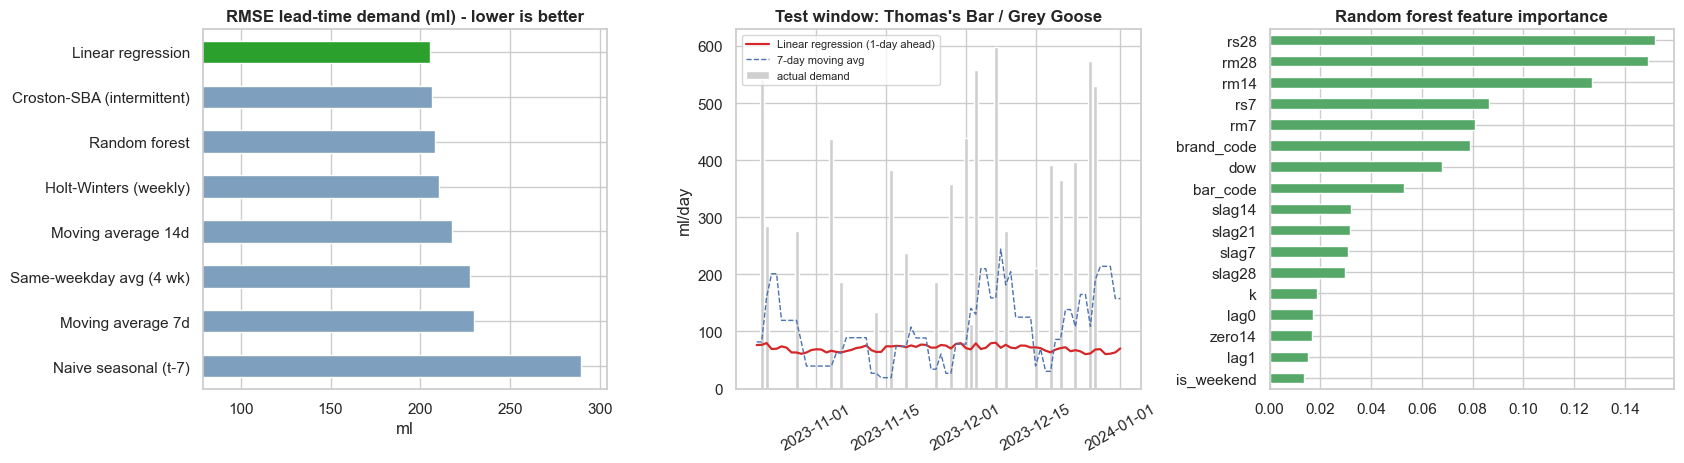

In [10]:
# ---------------- visuals: model comparison, forecast vs actual, feature importance ----------------
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
cm_ = cand[SELECTION_METRIC].sort_values(ascending=False)
cm_.plot.barh(ax=ax[0], color=["#2ca02c" if n == BEST_NAME else "#7f9fbf" for n in cm_.index]); ax[0].set_title(f"{SELECTION_METRIC} (ml) - lower is better"); ax[0].set_xlabel("ml"); ax[0].set_ylabel("")
lo_, hi_ = cm_.min(), cm_.max(); ax[0].set_xlim(left=max(0, lo_ - (hi_ - lo_) * 1.5))
best_cube = MODELS[BEST_NAME]
j_top = int(np.nanargmax(np.nansum(Y[split:], axis=0)))                                    # highest-volume series in the test window
te = np.arange(split, T)
ax[1].bar(dates[te], Y[te, j_top], color="#cfcfcf", label="actual demand", width=0.8)
ax[1].plot(dates[te], best_cube[0][te - 1, j_top], label=f"{BEST_NAME} (1-day ahead)", color="#d62728", lw=1.6)
ax[1].plot(dates[te], cube_ma7[0][te - 1, j_top], label="7-day moving avg", color="#4c72b0", lw=1, ls="--")
ax[1].set_title(f"Test window: {meta.loc[j_top, 'Bar Name']} / {meta.loc[j_top, 'Brand Name']}"); ax[1].set_ylabel("ml/day"); ax[1].legend(fontsize=8); ax[1].tick_params(axis="x", rotation=30)
imp = pd.Series(rf.feature_importances_, index=FEATS).sort_values()
imp.plot.barh(ax=ax[2], color="#55a868"); ax[2].set_title("Random forest feature importance")
fig.savefig(FIG_DIR / "forecast_evaluation.png"); plt.show()

## 5. Par level & safety stock

$$\text{Par Level} = \underbrace{\sum_{k=1}^{L}\hat y_{t+k}}_{\text{forecast demand during lead time}} + \underbrace{Z\cdot\sigma_{e}\cdot\sqrt{L}}_{\text{safety stock}}$$

* $L$ = supplier lead time (days); $\hat y_{t+k}$ = model forecast made at the end of day $t$, so the par level **is recomputed every day**.
* $\sigma_e$ = rolling **RMSE of the model's one-day-ahead forecast errors** over a trailing window (`SIGMA_WINDOW` = 56 days by default: ~9 demand events at this demand rate; a 28-day window is too noisy, see the sensitivity table in section 6) (the "forecast error RMSE x sqrt(L)" option in the brief); fallback: rolling std of demand.
* $Z$ = service-level factor. **Textbook (normal) Z**: 95% -> 1.645, 99% -> 2.326.

**Why Z needs care on this data.** The textbook Z assumes roughly *normal* lead-time demand errors. With ~84% zero-demand days the errors are highly skewed, and a 95% target measured over *all days* is only a fraction of the *demand events* actually served. We therefore report two versions:
1. **Normal Z** exactly as in the brief (1.645 / 2.326), and
2. **Calibrated Z**: the target-quantile of the standardised lead-time-demand errors $(y_{LT}-\hat y_{LT})/(\sigma_e\sqrt{L})$ measured **on the training window only**, over windows in which demand occurred - i.e. "serve 95% of demand events". No test data is used.

**Policies compared in the back-test** (same lead time, same simulator):
* *Static par, no safety stock* - training-average demand x L (naive manager rule)
* *Static par + safety stock (normal Z)* - the brief's formula with training-period mean/std, and the same with *calibrated Z* (the fair static baseline)
* *Dynamic par (normal Z)* - the brief's formula, recomputed daily
* *Dynamic par - 7-day moving average (calibrated)* - adaptive but simple forecast
* *Dynamic par - best model (calibrated)* at 95% and 99% service level (**recommended**)
* *Practical variant*: same as recommended but every order is at least one bottle (`MIN_ORDER_ML`), which cuts the number of tiny orders

In [11]:
def sigma_from_cube(cube, window=SIGMA_WINDOW, min_periods=SIGMA_MIN):
    E = np.full((T, S), np.nan); E[1:] = Y[1:] - cube[0][:-1]                        # error of yesterday's 1-day-ahead forecast, known at end of day t
    sig = pd.DataFrame(E).pow(2).rolling(window, min_periods=min_periods).mean().pow(0.5).values
    fallback = W.rolling(window, min_periods=min_periods).std().values
    return np.where(np.isnan(sig), fallback, sig)

def round_par(p):
    p = np.clip(p, 0, None)
    return np.ceil(p / BOTTLE_ML) * BOTTLE_ML if ROUND_PAR_TO_BOTTLE else p

def compute_par_level(predicted_demand_lt, std_daily_error, lead_time_days=LEAD_TIME_DAYS, service_level_z=Z):
    """Par = forecast demand during lead time + Z * sigma * sqrt(L). Returns (par, safety_stock)."""
    safety = service_level_z * std_daily_error * np.sqrt(lead_time_days)
    return round_par(predicted_demand_lt + safety), safety

def dynamic_par(cube, sig, L, z):
    return compute_par_level(cube[:L].sum(axis=0), sig, L, z)[0]

mu_tr, sd_tr = np.nanmean(Y[:split], axis=0), np.nanstd(Y[:split], axis=0, ddof=1)
STAT_SIG = np.tile(sd_tr, (T, 1)); stat_fc = lambda L: np.tile(mu_tr * L, (T, 1))
def static_par(L, z, ss=True):
    return round_par(stat_fc(L) + (z * STAT_SIG * np.sqrt(L) if ss else 0.0))

# ---- calibrated Z: quantile of standardised lead-time-demand errors on TRAINING origins, over windows with demand ----
YF = {k: W.shift(-k).values for k in range(1, KMAX + 1)}
ltd_act = lambda L: np.sum([YF[k] for k in range(1, L + 1)], axis=0)
def calibrate_z(ltd_fc, sig, L, sl):
    act = ltd_act(L); r = (act - ltd_fc) / (sig * np.sqrt(L))
    tr = np.zeros((T, S), bool); tr[: split - L] = True                              # origins whose whole lead-time window is inside the training period
    sel = tr & (act > 0) & np.isfinite(r) & (sig > 0)
    return float(np.quantile(r[sel], sl)) if sel.sum() >= 200 else float(norm.ppf(sl))

sig_best, sig_ma7 = sigma_from_cube(MODELS[BEST_NAME]), sigma_from_cube(cube_ma7)
L0 = LEAD_TIME_DAYS; Z99 = float(norm.ppf(0.99))
Zc = dict(static=calibrate_z(stat_fc(L0), STAT_SIG, L0, SERVICE_LEVEL), ma=calibrate_z(cube_ma7[:L0].sum(0), sig_ma7, L0, SERVICE_LEVEL),
          best=calibrate_z(MODELS[BEST_NAME][:L0].sum(0), sig_best, L0, SERVICE_LEVEL), best99=calibrate_z(MODELS[BEST_NAME][:L0].sum(0), sig_best, L0, 0.99))
print(f"Normal Z: {Z:.3f} (95%) / {Z99:.3f} (99%)  |  calibrated on training data (serve X% of demand events): static {Zc['static']:.2f}, 7d-MA {Zc['ma']:.2f}, "
      f"{BEST_NAME} {Zc['best']:.2f} (95%) / {Zc['best99']:.2f} (99%)")

P_STATIC0 = "Static par (no safety stock)"
P_STATIC_N = "Static par + SS (normal Z, 95%)"
P_DYN_N = f"Dynamic par - {BEST_NAME} (normal Z, 95%)"
P_STATIC = "Static par + SS (calibrated Z, 95%)"
P_DYN_MA = "Dynamic par - 7d moving avg (calibrated, 95%)"
P_DYN = f"Dynamic par - {BEST_NAME} (calibrated, 95%)"
P_DYN99 = f"Dynamic par - {BEST_NAME} (calibrated, 99%)"
P_DYN_B = f"Dynamic par - {BEST_NAME} (calibrated, 95%) + min order"
POL = {P_STATIC0: (static_par(L0, Z, ss=False), 0.0), P_STATIC_N: (static_par(L0, Z), 0.0),
       P_DYN_N: (dynamic_par(MODELS[BEST_NAME], sig_best, L0, Z), 0.0), P_STATIC: (static_par(L0, Zc["static"]), 0.0),
       P_DYN_MA: (dynamic_par(cube_ma7, sig_ma7, L0, Zc["ma"]), 0.0), P_DYN: (dynamic_par(MODELS[BEST_NAME], sig_best, L0, Zc["best"]), 0.0),
       P_DYN99: (dynamic_par(MODELS[BEST_NAME], sig_best, L0, Zc["best99"]), 0.0), P_DYN_B: (dynamic_par(MODELS[BEST_NAME], sig_best, L0, Zc["best"]), float(MIN_ORDER_ML))}
PAR = {n: v[0] for n, v in POL.items()}

# example recommendation table: par levels on the last day of data for the highest-volume series
last = T - 1; ex = np.argsort(-np.nansum(Y[split:], axis=0))[:8]
rec = pd.DataFrame({"Bar": meta.loc[ex, "Bar Name"].values, "Brand": meta.loc[ex, "Brand Name"].values, "Class": meta.loc[ex, "ABC"].values,
                    "Forecast demand over lead time (ml)": MODELS[BEST_NAME][:L0, last, :].sum(0)[ex],
                    "Safety stock 95% (ml)": (Zc["best"] * sig_best[last] * np.sqrt(L0))[ex],
                    "Recommended par 95% (ml)": PAR[P_DYN][last, ex], "Par 99% (ml)": PAR[P_DYN99][last, ex],
                    "Par, normal Z (ml)": PAR[P_DYN_N][last, ex], "Static par (ml)": PAR[P_STATIC][last, ex], "On hand (ml)": CL.values[last, ex]})
display(rec.style.format({c: "{:,.0f}" for c in rec.columns[3:]}).set_caption("Par-level recommendation for the latest date (top-8 series by volume)"))
rec.to_csv(TAB_DIR / "par_recommendation_latest.csv", index=False)

Normal Z: 1.645 (95%) / 2.326 (99%)  |  calibrated on training data (serve X% of demand events): static 3.04, 7d-MA 3.66, Linear regression 3.59 (95%) / 5.72 (99%)


,Bar,Brand,Class,Forecast demand over lead time (ml),Safety stock 95% (ml),Recommended par 95% (ml),Par 99% (ml),"Par, normal Z (ml)",Static par (ml),On hand (ml)
0,Thomas's Bar,Grey Goose,A,138,934,"1,072","1,628",567,838,"4,811"
1,Thomas's Bar,Yellow Tail,A,86,950,"1,036","1,601",522,592,"2,389"
2,Anderson's Bar,Jim Beam,A,134,"1,020","1,155","1,762",602,783,"4,519"
3,Taylor's Bar,Smirnoff,A,103,"1,016","1,119","1,724",569,738,"2,706"
4,Smith's Bar,Sutter Home,A,104,743,847,"1,289",445,685,"6,642"
5,Brown's Bar,Jameson,A,99,998,"1,097","1,691",557,758,"6,475"
6,Johnson's Bar,Grey Goose,A,119,907,"1,026","1,565",535,792,"4,141"
7,Taylor's Bar,Jim Beam,A,129,"1,073","1,202","1,840",621,724,"2,196"


## 6. Inventory simulation engine

A discrete daily loop, run **vectorised across all bar-brand series** on the **held-out test window only** (par levels use information available at the end of each day):

1. Start with initial stock (= the policy's own par at the start of the test window).
2. Each day: receive any order arriving today -> deduct actual customer consumption (unmet demand is **lost**, not backordered).
3. If **inventory position** (on hand + on order) is below the **reorder point** (= par level, i.e. an order-up-to / base-stock policy checked daily), order up to **par**.
4. The order arrives after the lead time of `L` days.
5. Track **stockout days**, **lost volume (ml)**, **average daily holding stock (ml)**, **turnover ratio**.

The vectorised engine is **validated against the reference loop from the brief** (`simulate_bar_inventory`) on random series before it is used.

In [12]:
def simulate(D, par, L, init, min_order=0.0):
    """D, par: (days x series) test-window demand and par (par[t] known at end of day t); init: starting stock per series."""
    Tt, S_ = D.shape
    stock = np.array(init, dtype=float); arr = np.zeros((Tt + L + 1, S_))
    st, lost, ordq = (np.zeros((Tt, S_)) for _ in range(3))
    for t in range(Tt):
        stock += arr[t]                                             # 1. receive orders arriving today
        served = np.minimum(stock, D[t]); lost[t] = D[t] - served    # 2. serve demand, the rest is lost
        stock -= served
        ip = stock + arr[t + 1: t + L].sum(axis=0)                   # 3. inventory position = on hand + on order (arriving t+1..t+L-1)
        q = np.where(ip < par[t], np.maximum(par[t] - ip, min_order), 0.0)   #    order up to par when below the reorder point (= par); optional minimum order size
        arr[t + L] += q                                              # 4. arrives after lead time
        st[t], ordq[t] = stock, q
    return {"stock": st, "lost": lost, "orders": ordq}

# ---- validation against the reference implementation from the brief ----
def simulate_bar_inventory(actual_demand, par_level, lead_time=2, initial_stock=5000):
    stock = initial_stock; stockouts = 0; lost_demand_volume = 0; pending_orders = []; history = []
    for day, demand in enumerate(actual_demand):
        for order in pending_orders:
            order[0] -= 1
            if order[0] == 0: stock += order[1]
        pending_orders = [o for o in pending_orders if o[0] > 0]
        if stock >= demand: stock -= demand
        else: lost_demand_volume += (demand - stock); stockouts += 1; stock = 0
        eff = stock + sum(o[1] for o in pending_orders)
        if eff < par_level: pending_orders.append([lead_time, par_level - eff])
        history.append(stock)
    return {"stockout_days": stockouts, "lost_volume_ml": lost_demand_volume, "average_inventory_ml": np.mean(history)}

D = Y[split:]; Tt = D.shape[0]
assert not np.isnan(D).any(), "NaN demand inside the test window"
rng = np.random.default_rng(1)
for j in rng.choice(S, size=min(6, S), replace=False):
    for L_chk in LEAD_TIMES_TO_TEST:
        par_c = float(np.nanmean(Y[:split, j]) * (L_chk + 1)); init_c = par_c
        ref = simulate_bar_inventory(D[:, j], par_c, L_chk, init_c)
        mine = simulate(D[:, [j]], np.full((Tt, 1), par_c), L_chk, [init_c])
        assert ref["stockout_days"] == int((mine["lost"] > 1e-9).sum()), (j, L_chk)
        assert np.isclose(ref["lost_volume_ml"], mine["lost"].sum()) and np.isclose(ref["average_inventory_ml"], mine["stock"].mean())
# invariants: no negative stock; served + lost = demand; zero par -> everything lost
chk = simulate(D, PAR[P_DYN][split:], LEAD_TIME_DAYS, PAR[P_DYN][split - 1])
assert (chk["stock"] >= -1e-6).all() and (chk["lost"] >= -1e-9).all()
assert np.isclose(simulate(D, np.zeros_like(D), LEAD_TIME_DAYS, np.zeros(S))["lost"].sum(), D.sum())
print("Simulator validated: matches the reference loop from the brief on random series, and passes invariant checks.")

Simulator validated: matches the reference loop from the brief on random series, and passes invariant checks.


In [13]:
def run_policy(par_full, L, min_order=0.0):
    fill = static_par(L, Z); p = np.where(np.isnan(par_full), fill, par_full)      # fallback for any undefined par
    return simulate(D, p[split:], L, p[split - 1], min_order)

def per_series(sim):
    return pd.DataFrame({"sid": W.columns, "stockout_days": (sim["lost"] > 1e-9).sum(0), "demand_days": (D > 0).sum(0),
                         "lost_ml": sim["lost"].sum(0), "demand_ml": D.sum(0), "avg_inv_ml": sim["stock"].mean(0),
                         "orders": (sim["orders"] > 0).sum(0)}).join(meta[["Bar Name", "Brand Name", "ABC"]])

def summarize(ps):
    dem, inv = ps["demand_ml"].sum(), ps["avg_inv_ml"].sum()
    return pd.Series({"Stockout days": ps["stockout_days"].sum(), "Stockout rate (% of demand days)": 100 * ps["stockout_days"].sum() / max(ps["demand_days"].sum(), 1),
                      "Lost volume (ml)": ps["lost_ml"].sum(), "Fill rate (%)": 100 * (1 - ps["lost_ml"].sum() / dem),
                      "Avg daily holding stock (ml)": inv, "Turnover (x per year)": dem / inv * 365 / Tt, "Days of cover": inv / (dem / Tt),
                      "Orders placed": ps["orders"].sum()})

SIMS = {n: run_policy(v[0], LEAD_TIME_DAYS, v[1]) for n, v in POL.items()}

# ---- Z sweeps (trade-off curves) and a STOCK-MATCHED static baseline for an apples-to-apples comparison ----
ZGRID = np.round(np.linspace(0.0, 8.0, 17), 2)
def sweep(kind, L):
    rows_ = []
    for z in ZGRID:
        par = static_par(L, z) if kind == "static" else dynamic_par(MODELS[BEST_NAME], sig_best, L, z)
        s_ = summarize(per_series(run_policy(par, L))); rows_.append({"z": z, "inv": s_["Avg daily holding stock (ml)"], "fill": s_["Fill rate (%)"], "svc": 100 - s_["Stockout rate (% of demand days)"], "so": s_["Stockout days"]})
    return pd.DataFrame(rows_).sort_values("inv").reset_index(drop=True)
def matched_static(L, inv_target, sw=None):
    sw = sweep("static", L) if sw is None else sw
    z = float(np.interp(inv_target, sw["inv"].values, sw["z"].values)); return z, summarize(per_series(run_policy(static_par(L, z), L)))
sw_static, sw_dyn = sweep("static", L0), sweep("dynamic", L0)
front = pd.concat([sw_static.assign(policy="Static par + SS"), sw_dyn.assign(policy=f"Dynamic ({BEST_NAME})")], ignore_index=True)
front["inv"] = front["inv"] / 1000                                            # litres, for plotting
dyn_inv_ml = float(per_series(SIMS[P_DYN])["avg_inv_ml"].sum())
Z_MATCH, _ = matched_static(L0, dyn_inv_ml, sw_static)
P_STATIC_M = "Static par + SS (same average stock as dynamic 95%)"
POL[P_STATIC_M] = (static_par(L0, Z_MATCH), 0.0); PAR[P_STATIC_M] = POL[P_STATIC_M][0]; SIMS[P_STATIC_M] = run_policy(PAR[P_STATIC_M], L0)
PS = {n: per_series(s) for n, s in SIMS.items()}
res_tbl = pd.DataFrame({n: summarize(p) for n, p in PS.items()}).T

# what actually happened in the same period (from the real balances)
n_purch = int(((full["sid"].isin(W.columns)) & (full["Date"] >= dates[split]) & (full["purchase"] > 0)).sum())
act_inv = float(np.nanmean(CL.values[split:], axis=0).sum()); act_so = int(np.nansum(SOS.values[split:]))      # demand days on which stock ran out while serving
hist_row = pd.Series({"Stockout days": act_so, "Stockout rate (% of demand days)": 100 * act_so / (D > 0).sum(), "Lost volume (ml)": np.nan, "Fill rate (%)": np.nan,
                      "Avg daily holding stock (ml)": act_inv, "Turnover (x per year)": D.sum() / act_inv * 365 / Tt, "Days of cover": act_inv / (D.sum() / Tt), "Orders placed": n_purch})
res_tbl.loc["Historical (actual, same period)"] = hist_row
FMT = {"Stockout days": "{:,.0f}", "Stockout rate (% of demand days)": "{:.2f}", "Lost volume (ml)": "{:,.0f}", "Fill rate (%)": "{:.2f}",
       "Avg daily holding stock (ml)": "{:,.0f}", "Turnover (x per year)": "{:.1f}", "Days of cover": "{:.1f}", "Orders placed": "{:,.0f}"}
display(res_tbl.style.format(FMT, na_rep="n/a").set_caption(f"Back-test on the held-out window ({dates[split].date()} to {dates[-1].date()}), L={LEAD_TIME_DAYS} d"))
res_tbl.to_csv(TAB_DIR / "simulation_results.csv")
print("Note: 'Historical' stockout days = demand days where the recorded consumption was capped by the stock on hand (observed); simulated stockout days = demand days where demand exceeded stock. Lost volume is not observable historically (demand is censored).")

# change of the recommended policy versus each baseline
def pct(a, b): return (a - b) / b * 100 if b else np.nan
chg = pd.DataFrame({base: {m: pct(res_tbl.loc[P_DYN, m], res_tbl.loc[base, m]) for m in ["Stockout days", "Lost volume (ml)", "Avg daily holding stock (ml)", "Orders placed"]}
                    for base in [P_STATIC0, P_STATIC_N, P_STATIC, P_DYN_MA]}).T
display(chg.style.format("{:+.1f}%").set_caption(f"% change of '{P_DYN}' versus each baseline"))
print(f"Target: serve {SERVICE_LEVEL:.0%} of demand events. Achieved on the test window - calibrated Z ({Zc['best']:.2f}): {100 - res_tbl.loc[P_DYN, 'Stockout rate (% of demand days)']:.1f}% "
      f"(fill rate {res_tbl.loc[P_DYN, 'Fill rate (%)']:.1f}%); textbook Z (1.645): {100 - res_tbl.loc[P_DYN_N, 'Stockout rate (% of demand days)']:.1f}% (fill rate {res_tbl.loc[P_DYN_N, 'Fill rate (%)']:.1f}%)")
print("=> With intermittent demand the textbook Z under-serves demand events; the calibrated Z is what makes the 95% target real.")

,Stockout days,Stockout rate (% of demand days),Lost volume (ml),Fill rate (%),Avg daily holding stock (ml),Turnover (x per year),Days of cover,Orders placed
Static par (no safety stock),"1,084",95.84,"283,235",28.43,"7,893",247.3,1.5,982
"Static par + SS (normal Z, 95%)",430,38.02,"69,412",82.46,"34,001",57.4,6.4,"1,081"
"Dynamic par - Linear regression (normal Z, 95%)",410,36.25,"68,374",82.72,"35,083",55.6,6.6,"1,979"
"Static par + SS (calibrated Z, 95%)",102,9.02,"18,773",95.26,"59,614",32.7,11.1,"1,126"
"Dynamic par - 7d moving avg (calibrated, 95%)",40,3.54,"7,732",98.05,"85,829",22.7,16.0,"2,079"
"Dynamic par - Linear regression (calibrated, 95%)",62,5.48,"11,071",97.20,"72,048",27.1,13.5,"1,966"
"Dynamic par - Linear regression (calibrated, 99%)",9,0.80,743,99.81,"114,265",17.1,21.4,"1,918"
"Dynamic par - Linear regression (calibrated, 95%) + min order",19,1.68,"2,885",99.27,"108,305",18.0,20.3,581
Static par + SS (same average stock as dynamic 95%),59,5.22,"10,101",97.45,"72,041",27.1,13.5,"1,127"
"Historical (actual, same period)",41,3.63,n/a,n/a,"269,552",7.2,50.4,315


Note: 'Historical' stockout days = demand days where the recorded consumption was capped by the stock on hand (observed); simulated stockout days = demand days where demand exceeded stock. Lost volume is not observable historically (demand is censored).


,Stockout days,Lost volume (ml),Avg daily holding stock (ml),Orders placed
Static par (no safety stock),-94.3%,-96.1%,+812.8%,+100.2%
"Static par + SS (normal Z, 95%)",-85.6%,-84.0%,+111.9%,+81.9%
"Static par + SS (calibrated Z, 95%)",-39.2%,-41.0%,+20.9%,+74.6%
"Dynamic par - 7d moving avg (calibrated, 95%)",+55.0%,+43.2%,-16.1%,-5.4%


Target: serve 95% of demand events. Achieved on the test window - calibrated Z (3.59): 94.5% (fill rate 97.2%); textbook Z (1.645): 63.7% (fill rate 82.7%)
=> With intermittent demand the textbook Z under-serves demand events; the calibrated Z is what makes the 95% target real.


,stockout_days | static,lost_ml | static,avg_inv_ml | static,stockout_days | dynamic,lost_ml | dynamic,avg_inv_ml | dynamic
ABC,,,,,,
A,88,"15,365","49,223",53,"9,074","60,228"
B,11,"3,032","6,727",9,"1,998","7,579"
C,3,375,"3,664",0,0,"4,241"


,stockout_days | static,lost_ml | static,avg_inv_ml | static,stockout_days | dynamic,lost_ml | dynamic,avg_inv_ml | dynamic
Bar Name,,,,,,
Anderson's Bar,14,"2,567","10,363",11,"1,678","12,051"
Brown's Bar,23,"5,343","9,910",11,"2,921","12,169"
Johnson's Bar,16,"2,739","10,048",10,"1,793","11,906"
Smith's Bar,16,"2,652","9,914",10,"1,561","11,790"
Taylor's Bar,26,"4,501","9,620",17,"2,803","11,781"
Thomas's Bar,7,971,"9,760",3,316,"12,351"


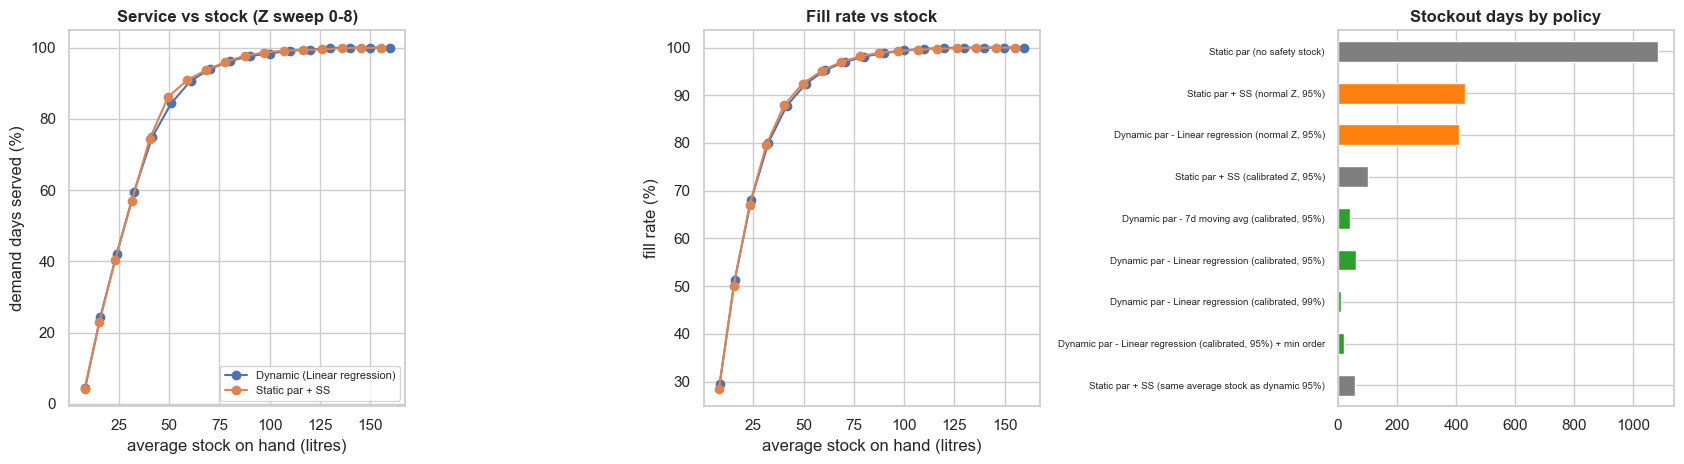

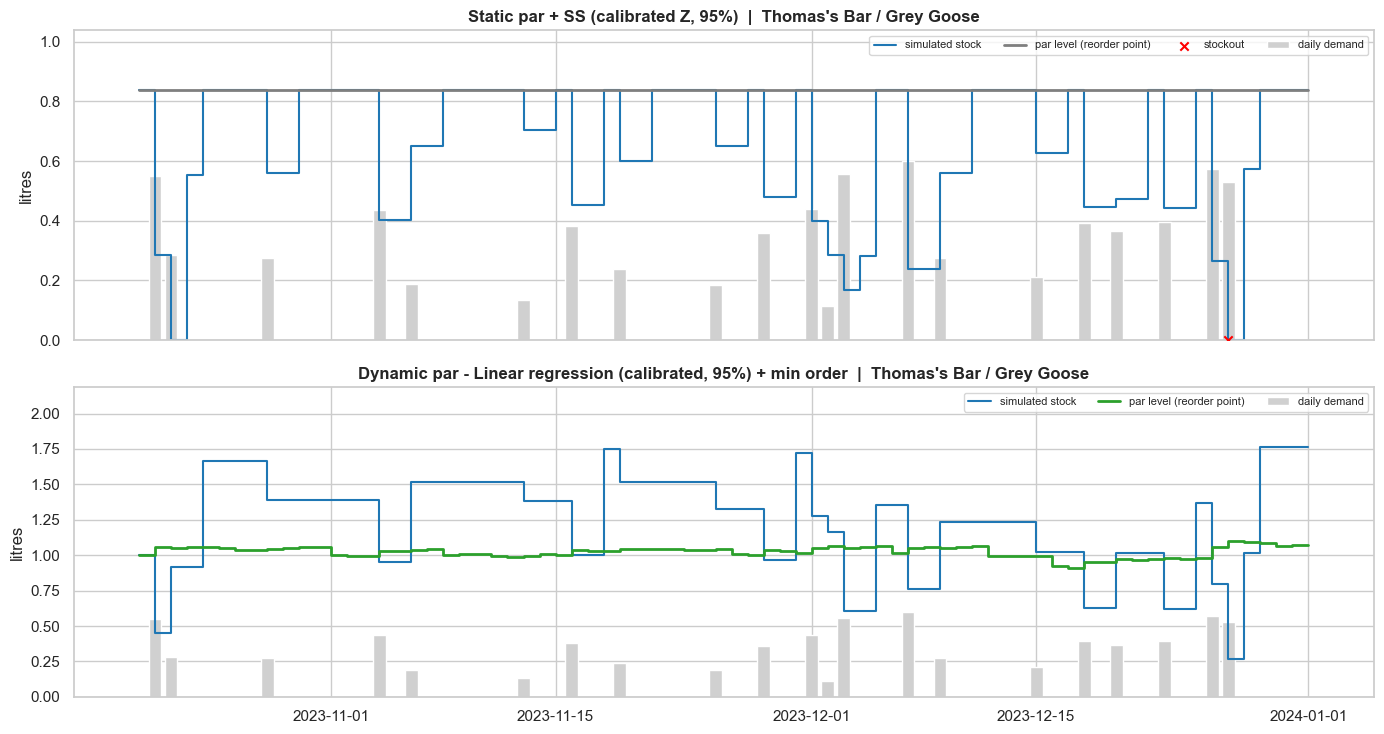

In [14]:
# ---------- breakdown by velocity class and by bar: recommended policy vs static par + safety stock ----------
def breakdown(key):
    a, b = PS[P_STATIC].groupby(key)[["stockout_days", "lost_ml", "avg_inv_ml"]].sum(), PS[P_DYN].groupby(key)[["stockout_days", "lost_ml", "avg_inv_ml"]].sum()
    out = a.join(b, lsuffix=" | static", rsuffix=" | dynamic"); return out
bd_abc, bd_bar = breakdown("ABC"), breakdown("Bar Name")
display(bd_abc.style.format("{:,.0f}").set_caption("By velocity class")); display(bd_bar.style.format("{:,.0f}").set_caption("By bar"))
bd_abc.to_csv(TAB_DIR / "sim_by_abc.csv"); bd_bar.to_csv(TAB_DIR / "sim_by_bar.csv")

# ---------- trade-off curve: sweep the service-level factor Z ----------
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
for name, g in front.groupby("policy"):
    ax[0].plot(g["inv"], g["svc"], marker="o", label=name); ax[1].plot(g["inv"], g["fill"], marker="o", label=name)
ax[0].set_xlabel("average stock on hand (litres)"); ax[0].set_ylabel("demand days served (%)"); ax[0].set_title("Service vs stock (Z sweep 0-8)"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("average stock on hand (litres)"); ax[1].set_ylabel("fill rate (%)"); ax[1].set_title("Fill rate vs stock")
kp = res_tbl.drop(index="Historical (actual, same period)")
kp["Stockout days"].plot.barh(ax=ax[2], color=["#2ca02c" if n.startswith("Dynamic") and "normal" not in n else ("#ff7f0e" if "normal" in n else "#7f7f7f") for n in kp.index]); ax[2].set_title("Stockout days by policy"); ax[2].invert_yaxis(); ax[2].tick_params(axis="y", labelsize=7)
fig.savefig(FIG_DIR / "tradeoff_and_kpis.png"); plt.show()

# ---------- simulated stock vs par for the highest-volume series ----------
fig, ax = plt.subplots(2, 1, figsize=(14, 7.5), sharex=True)
for a_, name, col in [(ax[0], P_STATIC, "#7f7f7f"), (ax[1], P_DYN_B, "#2ca02c")]:
    a_.bar(dates[split:], D[:, j_top] / 1000, color="#d0d0d0", label="daily demand")
    a_.step(dates[split:], SIMS[name]["stock"][:, j_top] / 1000, where="post", color="#1f77b4", label="simulated stock")
    a_.step(dates[split:], PAR[name][split:, j_top] / 1000, where="post", color=col, lw=2, label="par level (reorder point)")
    so_d = SIMS[name]["lost"][:, j_top] > 1e-9
    a_.scatter(dates[split:][so_d], np.zeros(so_d.sum()), color="red", marker="x", zorder=5, label="stockout" if so_d.any() else None)
    a_.set_title(f"{name}  |  {meta.loc[j_top, 'Bar Name']} / {meta.loc[j_top, 'Brand Name']}"); a_.set_ylabel("litres"); a_.set_ylim(top=a_.get_ylim()[1] * 1.18); a_.legend(fontsize=8, ncol=4, loc="upper right")
fig.savefig(FIG_DIR / "stock_vs_par.png"); plt.show()

In [15]:
# ---------- sensitivity: lead time x service level, recommended dynamic policy vs static par + safety stock ----------
sens = []
for L in LEAD_TIMES_TO_TEST:
    sw_L = sweep("static", L)
    for sl in SERVICE_LEVELS_TO_TEST:
        zd = calibrate_z(MODELS[BEST_NAME][:L].sum(0), sig_best, L, sl)                                # calibrated on training data for each L and target
        sd_ = summarize(per_series(run_policy(dynamic_par(MODELS[BEST_NAME], sig_best, L, zd), L)))
        zm, ss_ = matched_static(L, sd_["Avg daily holding stock (ml)"], sw_L)                         # static par given the SAME average stock
        sens.append({"Lead time (d)": L, "Service target": f"{sl:.0%}", "Calibrated Z": zd, "Avg stock (ml, equal)": sd_["Avg daily holding stock (ml)"],
                     "Stockouts static": ss_["Stockout days"], "Stockouts dynamic": sd_["Stockout days"], "Stockout change": pct(sd_["Stockout days"], ss_["Stockout days"]),
                     "Service static (%)": 100 - ss_["Stockout rate (% of demand days)"], "Service dynamic (%)": 100 - sd_["Stockout rate (% of demand days)"], "Fill rate dynamic (%)": sd_["Fill rate (%)"]})
sens = pd.DataFrame(sens)
display(sens.style.format({"Calibrated Z": "{:.2f}", "Avg stock (ml, equal)": "{:,.0f}", "Stockouts static": "{:,.0f}", "Stockouts dynamic": "{:,.0f}", "Stockout change": "{:+.1f}%",
                           "Service static (%)": "{:.1f}", "Service dynamic (%)": "{:.1f}", "Fill rate dynamic (%)": "{:.1f}"}).set_caption("Sensitivity: dynamic par vs static par at the SAME average stock (apples to apples)"))
sens.to_csv(TAB_DIR / "sensitivity_lead_time_service_level.csv", index=False)

,Lead time (d),Service target,Calibrated Z,"Avg stock (ml, equal)",Stockouts static,Stockouts dynamic,Stockout change,Service static (%),Service dynamic (%),Fill rate dynamic (%)
0,1,90%,3.84,"54,442",55,101,+83.6%,95.1,91.1,97.2
1,1,95%,4.62,"65,248",25,45,+80.0%,97.8,96.0,98.7
2,1,99%,7.07,"99,718",4,4,+0.0%,99.6,99.6,99.9
3,2,90%,2.84,"57,450",108,123,+13.9%,90.5,89.1,94.5
4,2,95%,3.59,"72,048",59,62,+5.1%,94.8,94.5,97.2
5,2,99%,5.72,"114,265",8,9,+12.5%,99.3,99.2,99.8
6,3,90%,2.46,"61,618",120,136,+13.3%,89.4,88.0,93.5
7,3,95%,3.18,"78,663",59,66,+11.9%,94.8,94.2,96.8
8,3,99%,5.16,"126,371",8,8,+0.0%,99.3,99.3,99.8


In [16]:
# ---------- sensitivity to the safety-stock window (sigma estimation), dynamic vs static at the SAME average stock ----------
wsens = []
for win in [28, 56, 90, 120]:
    sg = sigma_from_cube(MODELS[BEST_NAME], win, win // 2)
    zw = calibrate_z(MODELS[BEST_NAME][:L0].sum(0), sg, L0, SERVICE_LEVEL)
    sd_ = summarize(per_series(run_policy(dynamic_par(MODELS[BEST_NAME], sg, L0, zw), L0)))
    zm, ss_ = matched_static(L0, sd_["Avg daily holding stock (ml)"], sw_static)
    wsens.append({"Sigma window (days)": win, "Calibrated Z": zw, "Avg stock (ml, equal)": sd_["Avg daily holding stock (ml)"], "Stockouts static": ss_["Stockout days"], "Stockouts dynamic": sd_["Stockout days"],
                  "Service static (%)": 100 - ss_["Stockout rate (% of demand days)"], "Service dynamic (%)": 100 - sd_["Stockout rate (% of demand days)"]})
wsens = pd.DataFrame(wsens)
display(wsens.style.format({"Calibrated Z": "{:.2f}", "Avg stock (ml, equal)": "{:,.0f}", "Stockouts static": "{:,.0f}", "Stockouts dynamic": "{:,.0f}", "Service static (%)": "{:.1f}", "Service dynamic (%)": "{:.1f}"})
        .set_caption("Sensitivity to the sigma window: dynamic vs static par at equal average stock"))
wsens.to_csv(TAB_DIR / "sensitivity_sigma_window.csv", index=False)
print("Reading: a very short window (28 d) makes sigma noisy for intermittent demand, so dynamic par under-performs; from ~56 days the dynamic and static curves are close because this demand is stationary.")

,Sigma window (days),Calibrated Z,"Avg stock (ml, equal)",Stockouts static,Stockouts dynamic,Service static (%),Service dynamic (%)
0,28,4.15,"85,373",30,41,97.3,96.4
1,56,3.59,"72,048",59,62,94.8,94.5
2,90,3.43,"67,700",73,78,93.5,93.1
3,120,3.35,"65,890",75,88,93.4,92.2


Reading: a very short window (28 d) makes sigma noisy for intermittent demand, so dynamic par under-performs; from ~56 days the dynamic and static curves are close because this demand is stationary.


## 7. Results summary, assumptions & failure modes

The next cell collects every headline number in one place (`report/results_summary.json`). The PDF report, the video outline and the README results block are generated from **these numbers**, so nothing in the write-up is typed by hand.

In [17]:
AUTHOR = "Arun Ananthula"          # optional: your name for the report header

def chg_pct(new, old): return np.nan if (old is None or old == 0 or pd.isna(old)) else (new - old) / old * 100
def sgn(x, d=0): return "n/a" if pd.isna(x) else f"{x:+.{d}f}%"

pol = res_tbl.copy()
dyn, stat, stat0, dma, dyn99, hist, dynN, statN, dynB, statC = (pol.loc[n] for n in [P_DYN, P_STATIC_M, P_STATIC0, P_DYN_MA, P_DYN99, "Historical (actual, same period)", P_DYN_N, P_STATIC_N, P_DYN_B, P_STATIC])
# does the dynamic frontier beat the static one at equal average stock? (share of Z settings with a higher fill rate at the same stock)
fs_ = front[front["policy"] == "Static par + SS"].sort_values("inv"); fd_ = front[front["policy"] != "Static par + SS"]
inside = fd_[(fd_["inv"] >= fs_["inv"].min()) & (fd_["inv"] <= fs_["inv"].max())]
frontier_wins = int((inside["fill"].values > np.interp(inside["inv"].values, fs_["inv"].values, fs_["fill"].values) + 1e-9).sum()); frontier_n = len(inside)

RES = dict(
    n_rows_raw=int(DQ[0][1]), n_bars=int(full["Bar Name"].nunique()), n_brands=int(full["Brand Name"].nunique()), n_series=int(len(series_keys)), n_modelled=int(S),
    date_start=str(dates[0].date()), date_end=str(dates[-1].date()), n_days=int(T), train_end=str(dates[split - 1].date()), test_start=str(dates[split].date()), test_days=int(T - split),
    cons_ok_rate=float((~viol).mean()), zero_share=float((full["consumed"] == 0).mean()),
    so_days=int(so_days), series_days=int(tot_sd), so_rate=float(so_days / tot_sd), worst_bar=str(so_by_bar.index[0]), worst_bar_rate=float(so_by_bar["rate"].iloc[0]),
    est_lost_ml=est_lost_ml, cover_A=float(cover_abc.get("A", np.nan)), cover_C=float(cover_abc.get("C", np.nan)),
    peak_days=peak_days, peak_index=float(dow_index.max()),
    best=BEST_NAME, baseline=BASELINE_NAME, L=LEAD_TIME_DAYS, service=SERVICE_LEVEL, z=Z,
    wape1_best=float(model_tbl.loc[BEST_NAME, "WAPE next-day"]), wape1_base=float(model_tbl.loc[BASELINE_NAME, "WAPE next-day"]),
    wapeL_best=float(model_tbl.loc[BEST_NAME, LTD_COL]), wapeL_base=float(model_tbl.loc[BASELINE_NAME, LTD_COL]),
    so_dyn=float(dyn["Stockout days"]), so_stat=float(stat["Stockout days"]), so_stat0=float(stat0["Stockout days"]), so_hist=float(hist["Stockout days"]),
    inv_dyn=float(dyn["Avg daily holding stock (ml)"]), inv_stat=float(stat["Avg daily holding stock (ml)"]), inv_stat0=float(stat0["Avg daily holding stock (ml)"]), inv_hist=float(hist["Avg daily holding stock (ml)"]),
    lost_dyn=float(dyn["Lost volume (ml)"]), lost_stat=float(stat["Lost volume (ml)"]), lost_stat0=float(stat0["Lost volume (ml)"]),
    fill_dyn=float(dyn["Fill rate (%)"]), fill_stat=float(stat["Fill rate (%)"]), fill_dyn99=float(dyn99["Fill rate (%)"]), inv_dyn99=float(dyn99["Avg daily holding stock (ml)"]),
    turn_dyn=float(dyn["Turnover (x per year)"]), turn_stat=float(stat["Turnover (x per year)"]),
    d_so_vs_stat=chg_pct(dyn["Stockout days"], stat["Stockout days"]), d_so_vs_stat0=chg_pct(dyn["Stockout days"], stat0["Stockout days"]),
    d_inv_vs_stat=chg_pct(dyn["Avg daily holding stock (ml)"], stat["Avg daily holding stock (ml)"]), d_inv_vs_stat0=chg_pct(dyn["Avg daily holding stock (ml)"], stat0["Avg daily holding stock (ml)"]),
    d_lost_vs_stat=chg_pct(dyn["Lost volume (ml)"], stat["Lost volume (ml)"]), d_so_vs_ma=chg_pct(dyn["Stockout days"], dma["Stockout days"]),
    achieved_csl=float(100 - dyn["Stockout rate (% of demand days)"]), frontier_wins=frontier_wins, frontier_n=frontier_n,
    z_cal=Zc['best'], z_cal99=Zc['best99'], z_cal_static=Zc['static'], svc_dyn=float(100 - dyn['Stockout rate (% of demand days)']), svc_dynN=float(100 - dynN['Stockout rate (% of demand days)']), fill_dynN=float(dynN['Fill rate (%)']),
    so_dynN=float(dynN['Stockout days']), inv_dynN=float(dynN['Avg daily holding stock (ml)']), so_dynB=float(dynB['Stockout days']), inv_dynB=float(dynB['Avg daily holding stock (ml)']), fill_dynB=float(dynB['Fill rate (%)']),
    orders_dyn=float(dyn['Orders placed']), orders_dynB=float(dynB['Orders placed']), orders_hist=float(hist['Orders placed']), svc_stat=float(100 - stat['Stockout rate (% of demand days)']), svc_dyn99=float(100 - dyn99['Stockout rate (% of demand days)']),
    svc_dynB=float(100 - dynB['Stockout rate (% of demand days)']), turn_dynB=float(dynB['Turnover (x per year)']), lost_dynB=float(dynB['Lost volume (ml)']), sigma_window=SIGMA_WINDOW, turn_hist=float(hist['Turnover (x per year)']), z_match=Z_MATCH, so_statC=float(statC['Stockout days']), inv_statC=float(statC['Avg daily holding stock (ml)']), svc_statC=float(100 - statC['Stockout rate (% of demand days)']), svc_statM=float(100 - stat['Stockout rate (% of demand days)']),
    sel_metric=SELECTION_METRIC, sel_best=float(model_tbl.loc[BEST_NAME, SELECTION_METRIC]), sel_base=float(model_tbl.loc[BASELINE_NAME, SELECTION_METRIC]),
    wapeW_best=float(model_tbl.loc[BEST_NAME, W_COL]), wapeW_base=float(model_tbl.loc[BASELINE_NAME, W_COL]), rmse1_best=float(model_tbl.loc[BEST_NAME, 'RMSE (ml/day)']), rmse1_base=float(model_tbl.loc[BASELINE_NAME, 'RMSE (ml/day)']),
    weekday_effect=bool(WEEKDAY_EFFECT), dow_ratio=DOW_RATIO, adi_median=ADI_MEDIAN, n_capped=n_capped, n_records=n_rec, round_bottle=bool(ROUND_PAR_TO_BOTTLE), bottle_ml=BOTTLE_ML,
    n_A_brands=int(abc_tbl.loc['A', 'brands']) if 'A' in abc_tbl.index else 0, A_share=float(abc_tbl.loc['A', 'volume_share']) if 'A' in abc_tbl.index else float('nan'),
    sens_wins=int((sens['Stockouts dynamic'] < sens['Stockouts static']).sum()), sens_ties=int((sens['Stockouts dynamic'] == sens['Stockouts static']).sum()), sens_n=int(len(sens)), sens_median_change=float(sens['Stockout change'].median()),
    dq_rows=dq_table.astype(str).values.tolist(),
)
(ROOT / "report/results_summary.json").write_text(json.dumps(RES, indent=2, default=str))
display(pd.Series({k: v for k, v in RES.items() if k != "dq_rows"}).to_frame("value"))

,value
n_rows_raw,6575
n_bars,6
n_brands,16
n_series,96
n_modelled,96
...,...
A_share,0.852
sens_wins,0
sens_ties,2
sens_n,9


### Assumptions (also listed in the report)
* **Lead time is constant** (`L = 2` days, sensitivity for 1-3) and the supplier always has stock.
* **Lost sales, not backorders:** unmet demand disappears. Recorded `Consumed` = demand, but on stockout days demand is **censored** (true demand was higher) so forecasts can be slightly low for chronically stocked-out items.
* **Units:** balances are in ml; a standard bottle is assumed to be 750 ml (used for the minimum-order variant; par itself stays in ml).
* **Aggregation:** calendar days; explicit zero rows for days without sales; only bar-brand pairs that really occur are modelled; series with < 56 days of history before the split are excluded from modelling.
* **Policy:** order-up-to par, reviewed daily, no case-size constraint (a one-bottle minimum order is tested as a practical variant), initial stock = par. **Demand is censored** on the ~4% of records where stock ran out, so results for recorded history are indicative.
* **Safety stock:** the factor Z is **calibrated on the training window** (serve 95% of demand events) instead of assuming normal errors, because ~84% zero-demand days make errors very skewed; sigma is a trailing 56-day RMSE of one-day-ahead errors and is noisy for very slow movers.
* **Data quality:** conservation-equation violations are flagged and kept (share reported above); exact duplicates dropped.

### Failure modes to watch
Lead-time variance (a late truck wipes out the safety stock), holidays/events/promotions not in the features, pouring waste / breakage / comps that make balances drift, new brands (cold start), censored demand after stockouts, model chosen on the same test window (mild selection bias - use rolling-origin CV for production), and data-entry errors that break the balance equation.

## 8. Deliverables: PDF report, video outline, README block

In [18]:
import html as _html
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib.enums import TA_JUSTIFY
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, KeepTogether
from PIL import Image as PILImage

esc = lambda s: _html.escape(str(s))
L_ = lambda ml: f"{ml / 1000:,.0f}"
def words(x, lo='less', hi='more'):
    return f"{abs(x):.0f}% {lo if x < 0 else hi}"

def same_stock_phrase():
    d, so_d, so_s = RES["d_so_vs_stat"], RES["so_dyn"], RES["so_stat"]
    if so_d == so_s or (not pd.isna(d) and abs(d) < 15): return "about the same"
    return "better" if so_d < so_s else "worse"

def verdict_text():
    so_d, so_s, ph = RES["so_dyn"], RES["so_stat"], same_stock_phrase()
    if ph == "about the same":
        return (f"At equal average stock, dynamic and static par perform about the same ({so_d:,.0f} vs {so_s:,.0f} stockout days): this demand is stationary and intermittent with no weekday pattern, so a forecast-driven par adds little over a well-calibrated static par. "
                "Its value is automatic re-calibration when demand shifts (new brands, events, trends); the big gains here come from calibrated Z and right-sized stock.")
    if ph == "better": return f"At equal average stock the dynamic policy had {sgn(RES['d_so_vs_stat'])} stockout days versus static par ({so_d:,.0f} vs {so_s:,.0f})."
    return f"At equal average stock static par had fewer stockouts ({so_s:,.0f} vs {so_d:,.0f}); we would use calibrated static par for stable slow movers and dynamic par for high-velocity brands."

MODEL_NOTES = {
    "Random forest": "captures non-linear weekday x recent-level interactions and intermittency for all series in one model; trade-offs are lower interpretability and the need for periodic retraining",
    "Holt-Winters (weekly)": "is transparent (level + weekly seasonal factors) and cheap per series; trade-offs are one model per series and little benefit when there is no weekly pattern",
    "Croston-SBA (intermittent)": "is the classical method for intermittent demand (it smooths demand size and demand interval separately) and is very explainable; trade-off is that it ignores weekday and other drivers",
    "Linear regression": "is fast and interpretable with lag and weekday features; trade-off is that it cannot model interactions such as weekend x trend",
    "Same-weekday avg (4 wk)": "is a strong, fully explainable baseline that captures the weekly cycle; trade-off is no trend response and no learning across series",
    "Naive seasonal (t-7)": "simply repeats last week; explainable but noisy",
    "Moving average 7d": "is the simplest baseline but blind to weekday peaks",
    "Moving average 14d": "smooths noise but is blind to weekday peaks",
}

def build_report(path, fs):
    R_ = RES; sm = lambda **k: ParagraphStyle("s", fontName="Helvetica", fontSize=fs, leading=fs * 1.28, alignment=TA_JUSTIFY, **k)
    body, small = sm(spaceAfter=fs * 0.35), ParagraphStyle("c", fontName="Helvetica", fontSize=fs - 1.3, leading=(fs - 1.3) * 1.2, textColor=colors.HexColor("#444444"))
    h = ParagraphStyle("h", fontName="Helvetica-Bold", fontSize=fs + 1.6, leading=(fs + 1.6) * 1.2, textColor=colors.HexColor("#0b3d6b"), spaceBefore=fs * 0.6, spaceAfter=fs * 0.25)
    title = ParagraphStyle("t", fontName="Helvetica-Bold", fontSize=fs + 6.5, leading=(fs + 6.5) * 1.2, textColor=colors.HexColor("#0b3d6b"))
    bullet = ParagraphStyle("bl", parent=body, leftIndent=9, bulletIndent=0)
    doc = SimpleDocTemplate(str(path), pagesize=A4, leftMargin=1.6 * cm, rightMargin=1.6 * cm, topMargin=1.2 * cm, bottomMargin=1.1 * cm,
                            title="Hotel Bar Inventory Forecasting & Par Levels - Managerial Summary", author=AUTHOR or "")
    W_ = A4[0] - 3.2 * cm; st = []
    st.append(Paragraph("Hotel Bar Inventory Forecasting & Par Level Recommendation", title))
    st.append(Paragraph(esc(f"{AUTHOR + ' | ' if AUTHOR else ''}Krystal Ball assignment - managerial summary | data {R_['date_start']} to {R_['date_end']} ({R_['n_days']} days), {R_['n_bars']} bars, {R_['n_brands']} brands, "
                            f"{R_['n_modelled']} modelled bar-brand series | back-test {R_['test_start']} to {R_['date_end']} ({R_['test_days']} days), L = {R_['L']} days, {R_['service']:.0%} service level"), small))
    wk_short = (f"a clear weekly cycle ({esc(R_['peak_days'][0])} {R_['peak_index']:.2f}x average)" if R_["weekday_effect"] else f"no material weekday pattern (busiest day {R_['peak_index']:.2f}x average)")
    kf_items = [f"<b>Demand is intermittent:</b> {R_['zero_share']:.0%} of bar-brand-days have no consumption (~1 event per {R_['adi_median']:.0f} days), with {wk_short}. Balances satisfy the conservation equation on {R_['cons_ok_rate']:.1%} of rows (after repairing cells the source PDF had rounded).",
                f"<b>Forecasting:</b> {esc(R_['best'])} has the lowest lead-time-demand RMSE ({R_['sel_best']:,.0f} ml, {sgn(chg_pct(R_['sel_best'], R_['sel_base']))} vs the 7-day moving average). Daily WAPE is above 100% for every model because of the zeros, so weekly-total WAPE and RMSE are used.",
                f"<b>Par levels:</b> the textbook Z (1.645) served only {R_['svc_dynN']:.0f}% of demand events; a Z calibrated on training data ({R_['z_cal']:.2f}) serves {R_['svc_dyn']:.1f}% against the 95% target.",
                f"<b>Recommendation:</b> dynamic par with calibrated Z and a one-bottle minimum order: {R_['so_dynB']:,.0f} stockout days vs {R_['so_hist']:,.0f} recorded, with {sgn(chg_pct(R_['inv_dynB'], R_['inv_hist']))} average stock. At equal average stock, dynamic vs static par: {R_['so_dyn']:,.0f} vs {R_['so_stat']:,.0f} stockout days ({same_stock_phrase()})."]
    st.append(Paragraph("Key findings", h))
    for t in kf_items:
        st.append(Paragraph(t, bullet, bulletText="\u2022"))
    # 1
    over = " Slow movers are over-covered while fast movers run out." if (R_["cover_C"] > 1.5 * R_["cover_A"]) else ""
    if R_["weekday_effect"]:
        wk = f"Demand peaks on {esc(R_['peak_days'][0])} ({R_['peak_index']:.2f}x an average day), so a single flat par level is wrong most days of the week."
    else:
        wk = (f"There is no material weekday pattern (busiest day only {R_['peak_index']:.2f}x an average day). Demand is <b>intermittent</b>: {R_['zero_share']:.0%} of series-days have no consumption "
              f"(one demand event every ~{R_['adi_median']:.0f} days per bar-brand), so the risk lies in the size of the next demand event rather than in the day of the week.")
    st += [Paragraph("1. Core business problem & operational impact", h), Paragraph(
        f"Bars lose money in two opposite ways. <b>Stockouts</b>: a guest cannot order a popular brand or signature drink, revenue is lost and service is interrupted. "
        f"<b>Overstock</b>: excess bottles tie up working capital and scarce backroom space and raise shrinkage/spoilage risk. In the history analysed, "
        f"<b>{R_['so_days']:,} of {R_['series_days']:,} bar-brand-days ({R_['so_rate']:.1%})</b> ended with zero stock (worst bar: {esc(R_['worst_bar'])}, {R_['worst_bar_rate']:.1%}), and on "
        f"<b>{R_['n_capped']:,} of {R_['n_records']:,} recorded consumption events ({R_['n_capped'] / max(R_['n_records'], 1):.0%})</b> the stock ran out while serving, so recorded consumption understates true demand "
        f"(indicative unserved volume ~{R_['est_lost_ml'] / 1000:,.0f} litres). Meanwhile the median class-A series holds {R_['cover_A']:.1f} days of cover versus {R_['cover_C']:.1f} for class C.{over} {wk}", body)]
    # 2
    st += [Paragraph("2. Assumptions made", h)]
    for t in [f"Supplier lead time is constant at L = {R_['L']} days (sensitivity 1-3 days tested) and the supplier always has stock; unmet demand is <b>lost, not back-ordered</b>.",
              f"Recorded <i>Consumed</i> is demand; when stock runs out demand is censored (true demand was higher). Quantities are in ml (a standard bottle is assumed to be {BOTTLE_ML} ml)" + (", and par is rounded up to whole bottles." if R_["round_bottle"] else "; par levels and order quantities are in ml and not rounded to bottles, because typical daily use is a small fraction of a bottle."),
              f"Consumption is aggregated to calendar days per bar-brand with explicit zero-demand days; only pairs that really occur are modelled ({R_['n_modelled']} of {R_['n_series']}; the rest have too little history). "
              f"The balance equation Closing = Opening + Purchase - Consumed holds on {R_['cons_ok_rate']:.2%} of rows; violations are flagged and kept, duplicates dropped.",
              f"Replenishment is order-up-to par with a daily review, starting stock = par, no case-size constraint (a one-bottle minimum order is tested as a variant). The safety factor Z is <b>calibrated on training data</b> for the 'serve 95% of demand events' target instead of assuming normal errors, because {R_['zero_share']:.0%} zero-demand days make errors highly skewed; the forecast-error sigma uses a trailing {R_['sigma_window']}-day window."]:
        st.append(Paragraph(t, bullet, bulletText="\u2022"))
    # 3
    mt = model_tbl.copy(); hs_ = ParagraphStyle("hd", fontName="Helvetica-Bold", fontSize=fs - 1.6, leading=(fs - 1.6) * 1.1, alignment=1); rows_ = [[Paragraph(x, hs_) for x in ["Model", "WAPE next day", "WAPE weekly totals", "RMSE lead-time demand (ml)", "Bias next day"]]] + [[esc(i), f"{r['WAPE next-day']:.0%}", f"{r[W_COL]:.0%}", f"{r['RMSE lead-time demand']:,.0f}", f"{r['Bias next-day']:+.1%}"] for i, r in mt.iterrows()]
    tb = Table(rows_, colWidths=[W_ * .32, W_ * .15, W_ * .18, W_ * .21, W_ * .14]); best_i = list(mt.index).index(R_["best"]) + 1
    tb.setStyle(TableStyle([("FONT", (0, 0), (-1, -1), "Helvetica", fs - 1), ("FONT", (0, 0), (-1, 0), "Helvetica-Bold", fs - 1), ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#dbe8f5")),
                            ("BACKGROUND", (0, best_i), (-1, best_i), colors.HexColor("#d9f2dc")), ("TEXTCOLOR", (0, len(rows_) - 1), (-1, len(rows_) - 1), colors.HexColor("#777777")), ("GRID", (0, 0), (-1, -1), 0.3, colors.grey), ("ALIGN", (1, 0), (-1, -1), "CENTER"),
                            ("TOPPADDING", (0, 0), (-1, -1), 1.2), ("BOTTOMPADDING", (0, 0), (-1, -1), 1.2)]))
    d_sel = chg_pct(R_["sel_best"], R_["sel_base"])
    st += [Paragraph("3. Model selection & trade-offs", h), Paragraph(
        f"Compared on a strict temporal split (first 80% of days train, last 20% test) and on identical (day, series) cells: naive seasonal, moving averages, same-weekday average, Croston-SBA, Holt-Winters (weekly), linear regression and a global random forest with lag / rolling / weekday features. "
        f"Because {R_['zero_share']:.0%} of series-days are zero, an always-zero forecast scores exactly 100% daily WAPE while being useless, so daily WAPE (best model: {R_['wape1_best']:.0%}) is inflated for every model. "
        f"We therefore also report WAPE on weekly totals ({R_['wapeW_best']:.0%} for {esc(R_['best'])} vs {R_['wapeW_base']:.0%} for the 7-day moving average) and <b>rank models on the RMSE of lead-time demand</b>, the error that sets the safety stock. "
        f"<b>{esc(R_['best'])}</b> was chosen ({R_['sel_best']:,.0f} ml vs {R_['sel_base']:,.0f} ml for the 7-day moving average, {sgn(d_sel)}); it {MODEL_NOTES.get(R_['best'], '')}. "
        f"Selection was made on the same test window, so a production version should add rolling-origin validation.", body), tb]
    fig1 = FIG_DIR / "forecast_evaluation.png"; fig2 = FIG_DIR / "tradeoff_and_kpis.png"
    def img(p, wd):
        w, h_ = PILImage.open(p).size; return Image(str(p), width=wd, height=wd * h_ / w)
    st += [Spacer(1, 3), img(fig1, W_ * 0.98)]
    # 4
    kl = {P_STATIC: "Static par + SS (calibrated Z, 95%)", P_STATIC_M: "Static par at same avg stock as dynamic 95%", P_DYN_MA: "Dynamic par, 7-day MA (calibrated, 95%)", P_DYN_N: f"Dynamic par, {BEST_NAME} (textbook Z 1.645)",
          P_DYN: f"Dynamic par, {BEST_NAME} (calibrated, 95%)", P_DYN99: f"Dynamic par, {BEST_NAME} (calibrated, 99%)", P_DYN_B: f"Dynamic 95% + {MIN_ORDER_ML:,.0f} ml min. order (recommended)",
          "Historical (actual, same period)": "Historical (actual)"}
    cs = ParagraphStyle("k", fontName="Helvetica", fontSize=fs - 1.5, leading=(fs - 1.5) * 1.15)
    krows = [[Paragraph(x, hs_) for x in ["Policy", "Stockout days", "Demand days served", "Fill rate", "Lost volume (L)", "Avg stock (L)", "Turnover (x/yr)"]]]
    for k_, lab in kl.items():
        r = res_tbl.loc[k_]; krows.append([Paragraph(esc(lab), cs), f"{r['Stockout days']:,.0f}", f"{100 - r['Stockout rate (% of demand days)']:.1f}%", "n/a" if pd.isna(r["Fill rate (%)"]) else f"{r['Fill rate (%)']:.1f}%",
                                           "n/a" if pd.isna(r["Lost volume (ml)"]) else L_(r["Lost volume (ml)"]), L_(r["Avg daily holding stock (ml)"]), f"{r['Turnover (x per year)']:.1f}"])
    kt = Table(krows, colWidths=[W_ * .31, W_ * .11, W_ * .13, W_ * .09, W_ * .12, W_ * .12, W_ * .12])
    kt.setStyle(TableStyle([("FONT", (0, 0), (-1, 0), "Helvetica-Bold", fs - 1.5), ("FONT", (1, 1), (-1, -1), "Helvetica", fs - 1.5), ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#dbe8f5")),
                            ("BACKGROUND", (0, 7), (-1, 7), colors.HexColor("#d9f2dc")), ("GRID", (0, 0), (-1, -1), 0.3, colors.grey), ("ALIGN", (1, 0), (-1, -1), "CENTER"), ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
                            ("TOPPADDING", (0, 0), (-1, -1), 1.2), ("BOTTOMPADDING", (0, 0), (-1, -1), 1.2)]))
    st += [Paragraph("4. Performance & future improvements", h),
           Paragraph(f"<b>Forecast accuracy (test window):</b> lead-time-demand RMSE {R_['sel_best']:,.0f} ml for {esc(R_['best'])} vs {R_['sel_base']:,.0f} ml for the 7-day moving-average baseline ({sgn(chg_pct(R_['sel_best'], R_['sel_base']))}); "
                     f"weekly-total WAPE {R_['wapeW_best']:.0%} vs {R_['wapeW_base']:.0%}; next-day WAPE {R_['wape1_best']:.0%} vs {R_['wape1_base']:.0%} (an always-zero forecast scores 100%).", body),
           Paragraph(f"<b>Simulation ({R_['test_days']} days, L = {R_['L']}, target: serve {R_['service']:.0%} of demand events):</b>", body)]
    for t in [f"<b>Textbook vs calibrated Z.</b> Z = 1.645 served only {R_['svc_dynN']:.1f}% of demand events ({R_['so_dynN']:,.0f} stockout days) because zero-heavy demand is far from normal; Z calibrated on the training window ({R_['z_cal']:.2f} for 95%, {R_['z_cal99']:.2f} for 99%) served {R_['svc_dyn']:.1f}% ({R_['svc_dyn99']:.1f}% at 99%).",
              f"<b>Versus recorded history</b> ({R_['so_hist']:,.0f} demand days where stock ran out in the same window - indicative, as recorded demand is capped there - with {R_['inv_hist'] / 1000:,.0f} L on hand): calibrated dynamic par had {R_['so_dyn']:,.0f} stockout days with {R_['inv_dyn'] / 1000:,.0f} L ({sgn(chg_pct(R_['inv_dyn'], R_['inv_hist']))} stock). "
              f"<b>With a one-bottle minimum order (recommended)</b>: {R_['so_dynB']:,.0f} stockout days, fill rate {R_['fill_dynB']:.1f}%, {R_['inv_dynB'] / 1000:,.0f} L ({sgn(chg_pct(R_['inv_dynB'], R_['inv_hist']))} stock) and {R_['orders_dynB']:,.0f} orders vs {R_['orders_hist']:,.0f} recorded deliveries ({R_['orders_dyn']:,.0f} for the pure order-up-to rule).",
              f"<b>Dynamic vs static par at the same average stock:</b> {R_['so_dyn']:,.0f} vs {R_['so_stat']:,.0f} stockout days, lost volume {sgn(R_['d_lost_vs_stat'])}. {esc(verdict_text())} A naive static par without safety stock had {R_['so_stat0']:,.0f} stockout days."]:
        st.append(Paragraph(t, bullet, bulletText="\u2022"))
    st += [KeepTogether([kt]), Spacer(1, 3), img(fig2, W_ * 0.98),
           Paragraph("<b>Next steps:</b> promotion / event / holiday calendar features; live POS event feed instead of end-of-day logs; censored-demand correction after stockouts; probabilistic (quantile) forecasts and supplier lead-time distributions; "
                     "joint vendor delivery consolidation with a weekly review period and case-size / minimum-order constraints; rolling-origin cross-validation for model selection.", body)]
    # 5
    st += [Paragraph("5. Real-world deployment & production considerations", h)]
    for t in ["<b>Pipeline:</b> a nightly cron job ingests the day's balance logs, runs validation (conservation equation, duplicates, unit sanity), refreshes features, forecasts the next L days, recomputes par per bar-brand and writes a "
              "manager dashboard / CSV: on hand, par, forecast, <i>recommended order quantity</i> and stockout-risk alerts. Weekly refit of the ML model; a moving-average fallback if the job or model fails.",
              "<b>What breaks at scale:</b> supplier lead-time variance (a late delivery erodes safety stock), holiday and event shifts, pouring waste / breakage / comps that make balances drift from sales, new brands with no history, "
              "chronic stockouts that hide true demand, and per-series fitting cost as bars and SKUs grow (the global model scales better than per-series Holt-Winters).",
              "<b>Monitoring:</b> rolling WAPE and bias per bar and class vs the baseline, data-drift / level-shift detection on demand trends, achieved service level vs target, forecast MSE vs real orders, share of rows failing the balance check, and manager overrides as a feedback signal."]:
        st.append(Paragraph(t, bullet, bulletText="\u2022"))
    doc.build(st); return doc.page

REPORT_PATH = ROOT / "report/business_report.pdf"
for fs in [9.6, 9.2, 8.8, 8.4, 8.0, 7.6, 7.2, 6.8]:
    pages = build_report(REPORT_PATH, fs)
    if pages <= 2: break
print(f"Report written: {REPORT_PATH.relative_to(ROOT)} | font {fs} pt | {pages} page(s)")
if pages > 2: print("WARNING: report exceeds 2 pages - shorten the text or figures.")

Report written: report/business_report.pdf | font 8.4 pt | 2 page(s)


In [19]:
# ---------------- 3-5 minute video outline (structure from the assignment brief, numbers from this notebook) ----------------
R_ = RES
seg = {
 "Problem Statement": (
   "0:00 - 0:45",
   "Frame the tension: stockouts vs overstocking across multiple bars.",
   "Slide with the business goal and bar landscape (bars, brands, days).",
   f"Hi, I'm presenting my hotel bar inventory forecasting and par level solution. Bars have two opposite problems. Run out of a popular brand on a Friday night and you lose revenue and disappoint guests. "
   f"Over-order slow movers and you tie up cash and backroom space, with shrinkage risk. In this data - {R_['n_bars']} bars, {R_['n_brands']} brands, {R_['n_days']} days - {R_['so_days']:,} bar-brand days ended at zero stock, that is {R_['so_rate']:.1%}, "
   f"while the median class-C brand held {R_['cover_C']:.1f} days of cover against {R_['cover_A']:.1f} for class A.{' So stock is not aligned with velocity.' if R_['cover_C'] > R_['cover_A'] else ''} "
   f"My goal: forecast demand for every bar and brand, turn it into a par level that adapts to demand swings, and prove with a back-test that it cuts stockouts without piling up stock."),
 "Approach & Modeling": (
   "0:45 - 1:45",
   "Explain how raw bottle logs were processed into daily series, feature creation, and model choice.",
   "Notebook: EDA plots (eda_overview.png) and the daily demand chart; model comparison table (forecast_evaluation.png).",
   f"First the data. The file arrived as a PDF, so I converted it to CSV, repairing balance cells the PDF had rounded. I parsed timestamps and checked the conservation equation - closing equals opening plus purchase minus consumed - which holds on {R_['cons_ok_rate']:.2%} of rows. "
   f"I aggregated to daily consumption per bar and brand with explicit zero days, and that matters: {R_['zero_share']:.0%} of series-days have no sales, so demand is intermittent. "
   f"EDA shows a Pareto pattern - {R_['n_A_brands']} class-A brands carry {R_['A_share']:.0%} of volume - and " + (f"a clear weekly cycle: {R_['peak_days'][0]} runs at {R_['peak_index']:.2f} times an average day. " if R_['weekday_effect'] else f"no material weekday cycle - the busiest day is only {R_['peak_index']:.2f} times average. ") +
   f"I used a strict temporal 80/20 split, never random folds, and compared moving averages, Croston for intermittent demand, Holt-Winters, linear regression and a random forest, with lag, rolling and weekday features built only from information available at the forecast date. "
   f"Daily WAPE is inflated by all those zeros, so I also report weekly-total WAPE and rank models on the RMSE of lead-time demand, which is what drives safety stock. "
   f"{R_['best']} won: {R_['sel_best']:,.0f} ml against {R_['sel_base']:,.0f} for the seven-day moving average, {words(chg_pct(R_['sel_best'], R_['sel_base']), 'lower', 'higher')}."),
 "Inventory Logic & Simulation": (
   "1:45 - 3:00",
   "Walk through the Par Level math (Z x sigma x sqrt(L)) and show the back-test loop results.",
   "Plot showing simulated stock level vs par line over time (stock_vs_par.png); trade-off curve (tradeoff_and_kpis.png).",
   f"Now the par level. Par equals forecast demand over the {R_['L']}-day supplier lead time, plus safety stock: Z times the forecast-error standard deviation times the square root of the lead time. The textbook Z of {R_['z']:.3f} assumes normal errors; with this zero-heavy demand it served only {R_['svc_dynN']:.0f}% of demand events, "
   f"so I calibrated Z on the training data: {R_['z_cal']:.1f} for a 95% target. "
   + ("Because the forecast follows the weekday pattern, the par line moves - higher before the weekend, lower midweek - as you can see in this plot. " if R_['weekday_effect'] else "Because demand is intermittent, par is mostly a safety buffer against the next demand event, and it updates every day as the forecast and error estimates move, as you can see in this plot. ") +
   (f"Par is rounded up to whole bottles. " if R_['round_bottle'] else "Par is expressed in ml. ") +
   ""
   f"To test it I built a daily simulation on the held-out test window: receive arriving orders, serve demand, count anything unserved as lost, and order up to par when inventory position drops below it. I validated my vectorised engine against the reference loop from the brief. "
   f"Against the recorded history, the calibrated policy with a one-bottle minimum order had {R_['so_dynB']:,.0f} stockout days versus {R_['so_hist']:,.0f} while holding {words(chg_pct(R_['inv_dynB'], R_['inv_hist']))} stock. "
   f"Against a static par held at the same average stock, dynamic par was {same_stock_phrase()}: {R_['so_dyn']:,.0f} versus {R_['so_stat']:,.0f} stockout days" + (" - which makes sense, because this demand has no weekly pattern to exploit. " if same_stock_phrase() == "about the same" else ". ") +
   f"The big win is calibrating Z: the textbook value served {R_['svc_dynN']:.0f}% of demand events, the calibrated one {R_['svc_dyn']:.0f}%."),
 "Business Impact & Scalability": (
   "3:00 - 4:00",
   "Summarize the reduction in stockouts, how managers use it daily, and production risks.",
   "Final summary slide / KPI comparison table (simulation_results.csv).",
   f"The recommended policy - calibrated dynamic par with a one-bottle minimum order - serves {R_['svc_dynB']:.1f}% of demand events with a {R_['fill_dynB']:.1f}% fill rate, and stock turns {R_['turn_dynB']:.1f} times a year versus {R_['turn_hist']:.1f} in the recorded history. "
   f"It uses {R_['orders_dynB']:,.0f} orders, against {R_['orders_hist']:,.0f} recorded deliveries and {R_['orders_dyn']:,.0f} for the pure order-up-to rule. "
   f"In production, a nightly job ingests the day's logs, validates them, refreshes forecasts and writes a manager dashboard: on hand, par and recommended order per bar and brand. "
   f"What can break: supplier lead-time variance, holidays and events, pouring waste, new brands with no history, and demand hidden by stockouts. I would monitor rolling WAPE and bias, data drift and achieved service level. "
   f"Next steps: an event calendar, a live point-of-sale feed, consolidated weekly deliveries and probabilistic forecasts. Thank you for watching."),
}
lines = ["# Video Walkthrough Outline (target 4:00, within the 3-5 minute brief)", "",
         "> Numbers below are generated from the notebook run. Read them off the notebook output while recording; speak at ~150 words per minute.", "",
         "| Time | Section | Talking Points | Visual to Show |", "|---|---|---|---|"]
for name, (tm, tp_, vis, _) in seg.items():
    lines.append(f"| {tm} | **{name}** | {tp_} | {vis} |")
lines.append("")
tot_w = 0
for name, (tm, tp_, vis, say) in seg.items():
    nw = len(say.split()); tot_w += nw
    lines += [f"## {tm} - {name}", f"- **Talking points:** {tp_}", f"- **Show:** {vis}", f"- **Script (~{nw} words = ~{nw / 150 * 60:.0f} s):**", "", f"  > {say}", ""]
lines += [f"**Total script: ~{tot_w} words = ~{tot_w / 150:.1f} min at 150 wpm.**", "",
          "## Recording checklist",
          "- Restart & Run All first so every number and plot on screen matches the report.",
          "- Screen order: slide (problem) -> notebook EDA -> model table -> par formula cell -> simulation plot -> KPI table -> slide (impact).",
          "- Say the assumptions out loud once (constant lead time, lost sales, ml units, order-up-to daily review).",
          "- Mention one honest limitation: model selected on the same test window; production would use rolling-origin validation.",
          "- Keep the video between 3:00 and 5:00."]
(ROOT / "video_script/video_walkthrough_outline.md").write_text("\n".join(lines))
print(f"Video outline written | script ~{tot_w} words = ~{tot_w / 150:.1f} min")

# ---------------- README results block ----------------
block = (f"<!-- RESULTS:START -->\n**Auto-generated from the last notebook run** ({R_['date_start']} to {R_['date_end']}, back-test {R_['test_start']} onward, L={R_['L']} d, {R_['service']:.0%} service level)\n\n"
         f"| Metric | Value |\n|---|---|\n| Best forecaster (lead-time-demand RMSE) | {R_['best']} ({R_['sel_best']:,.0f} ml) |\n| Baseline (7-day MA) lead-time-demand RMSE | {R_['sel_base']:,.0f} ml |\n"
         f"| Stockout days: dynamic vs static par at equal average stock | {R_['so_dyn']:,.0f} vs {R_['so_stat']:,.0f} ({sgn(R_['d_so_vs_stat'])}) |\n| Average stock: dynamic (order-up-to) vs recorded history | {R_['inv_dyn']/1000:,.0f} L vs {R_['inv_hist']/1000:,.0f} L ({sgn(chg_pct(R_['inv_dyn'], R_['inv_hist']))}) |\n"
         f"| Recommended policy (dynamic, calibrated Z {R_['z_cal']:.2f}, 1-bottle min. order): stockout days vs recorded history | {R_['so_dynB']:,.0f} vs {R_['so_hist']:,.0f} |\n| Recommended policy: average stock vs recorded history | {R_['inv_dynB']/1000:,.0f} L vs {R_['inv_hist']/1000:,.0f} L ({sgn(chg_pct(R_['inv_dynB'], R_['inv_hist']))}) |\n| Demand events served / fill rate (dynamic 95%, calibrated Z {R_['z_cal']:.2f}) | {R_['svc_dyn']:.1f}% / {R_['fill_dyn']:.1f}% |\n| Textbook Z 1.645: demand events served | {R_['svc_dynN']:.1f}% |\n<!-- RESULTS:END -->")
rp = ROOT / "README.md"
if rp.exists():
    txt = rp.read_text()
    txt = re.sub(r"<!-- RESULTS:START -->.*?<!-- RESULTS:END -->", lambda m: block, txt, flags=re.S) if "<!-- RESULTS:START -->" in txt else txt + "\n" + block + "\n"
    rp.write_text(txt)
print("Files written:", *[str(p.relative_to(ROOT)) for p in [PROC_PATH, REPORT_PATH, ROOT / "video_script/video_walkthrough_outline.md", ROOT / "report/results_summary.json"]], sep="\n - ")

Video outline written | script ~661 words = ~4.4 min
Files written:
 - data/processed/daily_bar_consumption.csv
 - report/business_report.pdf
 - video_script/video_walkthrough_outline.md
 - report/results_summary.json
